# Fish database analysis

Load every worksheet from `crosses.xlsx` and `fish_database.xlsx`, then summarize the resulting tables.

In [36]:
# Path handles files and folders in a platform-independent way.
from pathlib import Path

# pandas reads Excel sheets and stores them as tables; these libraries create plots.
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns


# This folder contains the Excel workbooks used by the notebook.
DATA_DIR = Path(r"C:\Users\crodri19\larschpostdoc_analyses\data\fishinfo")
# Give each workbook a short name so later code can refer to it clearly.
WORKBOOK_PATHS = {
    "crosses.xlsx": DATA_DIR / "crosses.xlsx",
    "fish_database.xlsx": DATA_DIR / "fish_database.xlsx",
}

# Stop early with a useful message if a required input file is missing.
missing_workbooks = [str(path) for path in WORKBOOK_PATHS.values() if not path.is_file()]
if missing_workbooks:
    raise FileNotFoundError(f"Missing workbook(s): {missing_workbooks}")

# Read every worksheet. The result is workbook name -> sheet name -> table.
fish_workbooks = {
    workbook_name: pd.read_excel(workbook_path, sheet_name=None)
    for workbook_name, workbook_path in WORKBOOK_PATHS.items()
}

# Build an inventory so it is easy to see what was loaded.
sheet_summary = pd.DataFrame(
    [
        {
            "workbook": workbook_name,
            "sheet": sheet_name,
            "data_rows": sheet_data.shape[0],
            "columns": sheet_data.shape[1],
        }
        for workbook_name, sheets in fish_workbooks.items()
        for sheet_name, sheet_data in sheets.items()
    ]
).sort_values(["workbook", "sheet"], ignore_index=True)

display(sheet_summary)


c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


,workbook,sheet,data_rows,columns
0,crosses.xlsx,Crosses efficiency,432,23
1,crosses.xlsx,Laying frequency,999,19
2,fish_database.xlsx,Fish lines,99,23
3,fish_database.xlsx,Fish moves,2999,91
4,fish_database.xlsx,Tanks,999,101
5,fish_database.xlsx,Users,124,22


## Crossing efficiency analysis

The worksheet uses a four-row header. The settings below control the selection-line and crossing-type filters.

In [37]:
# User-editable filters for the crossing-efficiency analysis.
# Keep the line token broad enough to include every selection-line name.
SELECTION_LINE_TOKEN = "sel"
# Only rows with this crossing type are used in the summaries and plots.
CROSSING_TYPE_FILTER = "incross"
# Date boundaries are optional and inclusive. None means that boundary is disabled.
CROSSING_DATE_START = None
CROSSING_DATE_END = None
# Age classes use 30-day months; change this positive value to widen or narrow the bins.
AGE_BIN_MONTHS = 1
# Choose lineage/line colours, or one neutral bar with no grouping colours.
INCROSS_FAILURE_COLOR_BY = "none"  # Valid values: "lineage", "line", "none"
# User-editable ancestry groups. Dictionary order controls lineage stack/legend order.
LINEAGE_GROUPS = {
    "selection 1 hi": [
        "TL sel1 hi8", "TL sel1 hi9", "TL sel1 hi10",
        "TL sel1 hi11", "TL sel1 hi12",
    ],
    "selection 1 lo": [
        "TL sel1 lo8", "TL sel1 lo9xTLN",
        "TL sel1 lo10", "TL sel1 lo11",
    ],
    "selection 1 hi gc": [
        "sel1 hi10xGC", "TL sel1 gc hi8", "TL sel1 gc hi9",
        "TLSel GC Hi",
    ],
    "selection 1 lo gc": [
        "TL sel1 gc lo8", "TL sel1 gc lo9", "TLSel GC Lo",
    ],
    "selection 3 hi": [
        "TL sel3 hi7", "TL sel3 hi7b", "TL sel3 hi8", "TL sel3 hi9",
    ],
    "selection 3 lo": ["TL sel3 lo7", "TL sel3 lo8", "TL sel3 lo9"],
    "selection 3 mid": ["TL sel mid10", "TL sel3 mid11"],
    "sel1 f1": [
        "Sel1 G10 F1A", "Sel1 G10 F1B", "Sel1 G10 F1C", "Sel1 G10 F1D",
    ],
    "sel3 f1": [
        "Sel3 G8 F1A", "Sel3 G8 F1B", "Sel3 G8 F1C", "Sel3 G8 F1D",
    ],
}
# Choose original category colours, or stack mortality bars by line or lineage.
MORTALITY_COLOR_BY = "none"  # Valid values: "none", "line", "lineage"


# Valid values: "all", or one/more of: Sel1 G10 F1A, Sel1 G10 F1B, Sel1 G10 F1C,
# Sel1 G10 F1D, sel1 hi10xGC, sel3 g7 F1A, sel3 g7 F1B, Sel3 G8 F1A,
# Sel3 G8 F1B, Sel3 G8 F1C, Sel3 G8 F1D, TL sel mid10, TL sel1 gc hi8,
# TL sel1 gc hi9, TL sel1 gc lo8, TL sel1 gc lo9, TL sel1 hi10,
# TL sel1 hi11, TL sel1 hi12, TL sel1 hi8, TL sel1 hi9, TL sel1 lo10,
# TL sel1 lo11, TL sel1 lo8, TL sel1 lo9xTLN, TL sel1 lo9xTLN inx,
# TL sel3 hi7, TL sel3 hi7b, TL sel3 hi8, TL sel3 hi9, TL sel3 lo7,
# TL sel3 lo8, TL sel3 lo9, TL sel3 mid11, TLSel GC Hi,
# TLSel GC Hi outX Hi5, TLSel GC Lo.
MORTALITY_LINE_FILTER = "all"

In [38]:
# Load the crossing-efficiency worksheet. header=4 means the real column names are on row 5.
crosses_efficiency = pd.read_excel(
    WORKBOOK_PATHS["crosses.xlsx"],
    sheet_name="Crosses efficiency",
    header=4,
)

# The crossing date is the event date used by the optional date filter.
cross_date_column = crosses_efficiency.columns[14]

# This helper is reused below so both analysis branches apply the same date rules.
def crossing_date_filter(date_values):
    """Return True for dates inside the user-selected inclusive range."""
    dates = pd.to_datetime(date_values, errors="coerce", format="mixed")
    try:
        start = (
            pd.Timestamp(CROSSING_DATE_START).normalize()
            if CROSSING_DATE_START is not None
            else None
        )
        end = (
            pd.Timestamp(CROSSING_DATE_END).normalize()
            if CROSSING_DATE_END is not None
            else None
        )
    except (TypeError, ValueError) as error:
        raise ValueError("CROSSING_DATE_START and CROSSING_DATE_END must be valid dates or None.") from error
    if start is not None and end is not None and start > end:
        raise ValueError("CROSSING_DATE_START cannot be later than CROSSING_DATE_END.")

    # With no boundaries, leave every row untouched: None means no date filtering.
    if start is None and end is None:
        return pd.Series(True, index=dates.index)

    # Use midnight at the next day so every time on the end date is included.
    mask = dates.notna()
    if start is not None:
        mask &= dates >= start
    if end is not None:
        mask &= dates < end + pd.Timedelta(days=1)
    return mask

male_line = crosses_efficiency["Strain ♂"].astype("string")
female_line = crosses_efficiency["Strain ♀"].astype("string")
selection_mask = (
    male_line.str.contains(SELECTION_LINE_TOKEN, case=False, na=False)
    | female_line.str.contains(SELECTION_LINE_TOKEN, case=False, na=False)
)
# Keep only the requested crossing type, ignoring capitalization and extra spaces.
crossing_type_mask = (
    crosses_efficiency["crossing type"].astype("string").str.strip().str.casefold()
    == CROSSING_TYPE_FILTER.strip().casefold()
)
# With both date settings None, every row with a valid crossing date passes this mask.
crossing_date_mask = crossing_date_filter(crosses_efficiency[cross_date_column])
selection_crosses_efficiency = crosses_efficiency.loc[
    selection_mask & crossing_type_mask & crossing_date_mask
].copy()

# Keep both male and female tank/line roles so each line is linked to its tanks.
selection_tanks = pd.concat(
    [
        selection_crosses_efficiency[["N° Tank ♂", "Strain ♂"]].rename(
            columns={"N° Tank ♂": "tank_id", "Strain ♂": "line_name"}
        ),
        selection_crosses_efficiency[["N° Tank ♀", "Strain ♀"]].rename(
            columns={"N° Tank ♀": "tank_id", "Strain ♀": "line_name"}
        ),
    ],
    ignore_index=True,
).dropna(subset=["tank_id", "line_name"])
# Standardize text before grouping: trim spaces and make tank IDs case-insensitive.
selection_tanks["tank_id"] = selection_tanks["tank_id"].astype("string").str.strip().str.upper()
selection_tanks["line_name"] = selection_tanks["line_name"].astype("string").str.strip()
selection_tanks = selection_tanks[selection_tanks["line_name"].str.contains(SELECTION_LINE_TOKEN, case=False, na=False)].drop_duplicates()

# Summarize the unique tank IDs associated with each selection line.
selection_line_tank_summary = (
    selection_tanks.groupby("line_name", as_index=False)["tank_id"]
    .agg(lambda values: ", ".join(sorted(values.unique())))
    .rename(columns={"tank_id": "tank_ids"})
    .sort_values("line_name", ignore_index=True)
)

# Show both the filtered raw rows and the compact line-to-tank summary.
display(selection_crosses_efficiency)
display(selection_line_tank_summary)

,Cross N°,N° Tank ♂,Strain ♂,genotype 1 ♂,genotype 2 ♂,day of fertilization ♂,# ♂,N° Tank ♀,Strain ♀,genotype 1 ♀,...,Person,Date crossing,crossing type,successful?,day of raised,# raised,How many new tank,To do for selection,Comments eggs,Unnamed: 22
0,1,L031,TLSel GC Hi,WT,NaN,Johannes,2,L032,TLSel GC Hi,WT,...,Yann,2024-04-30 00:00:00,incross,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2,L032,TLSel GC Hi,WT,NaN,Johannes,1,L031,TLSel GC Hi,WT,...,Yann,2024-04-30 00:00:00,incross,0,NaN,NaN,NaN,NaN,NaN,NaN
2,3,L009,TL sel1 hi8,WT,NaN,Johannes,4,L009,TL sel1 hi8,WT,...,Yann,2024-04-30 00:00:00,incross,0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,L010,TL sel1 lo8,WT,NaN,Johannes,4,L010,TL sel1 lo8,WT,...,Yann,2024-04-30 00:00:00,incross,0,NaN,NaN,NaN,NaN,NaN,NaN
4,5,L035,TL sel3 lo7,WT,NaN,Johannes,6,L035,TL sel3 lo7,WT,...,Yann,2024-04-30 00:00:00,incross,1,NaN,NaN,2 new tanks,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,424,L550,Sel1 G10 F1C,WT,NaN,2025-11-05 00:00:00,NaN,NaN,NaN,NaN,...,Carlos,2026-07-14 00:00:00,incross,0,NaN,NaN,NaN,NaN,NaN,NaN
424,425,L573,Sel1 G10 F1D,WT,NaN,2025-11-13 00:00:00,NaN,NaN,NaN,NaN,...,Carlos,2026-07-14 00:00:00,incross,0,NaN,NaN,NaN,NaN,NaN,NaN
425,426,L541,Sel3 G8 F1A,WT,NaN,2025-10-30 00:00:00,NaN,NaN,NaN,NaN,...,Carlos,2026-07-14 00:00:00,incross,1,NaN,NaN,NaN,NaN,NaN,NaN
426,427,L551,Sel1 G10 F1C,WT,NaN,2025-11-05 00:00:00,NaN,NaN,NaN,NaN,...,Carlos,2026-07-14 00:00:00,incross,0,NaN,NaN,NaN,NaN,All eggs dead 24h,NaN


,line_name,tank_ids
0,Sel1 G10 F1A,"L547, L548"
1,Sel1 G10 F1C,"L550, L551"
2,Sel1 G10 F1D,L573
3,Sel3 G8 F1A,L541
4,Sel3 G8 F1B,L542
5,Sel3 G8 F1C,"L545, L546"
6,TL sel mid10,"L228, L402, L403"
7,TL sel1 gc hi8,L581
8,TL sel1 gc hi9,L680
9,TL sel1 gc lo8,L582


,family,line_name,crossings,successful_crossings,success_percentage
0,sel1,Sel1 G10 F1A,2,2.0,100.0
1,sel1,Sel1 G10 F1C,4,0.0,0.0
2,sel1,Sel1 G10 F1D,2,0.0,0.0
3,sel1,TL sel1 gc hi9,2,2.0,100.0
4,sel1,TL sel1 gc lo9,1,1.0,100.0
5,sel1,TL sel1 hi10,6,5.0,83.333333
6,sel1,TL sel1 hi11,3,3.0,100.0
7,sel1,TL sel1 hi8,1,0.0,0.0
8,sel1,TL sel1 hi9,16,11.0,68.75
9,sel1,TL sel1 lo10,4,4.0,100.0


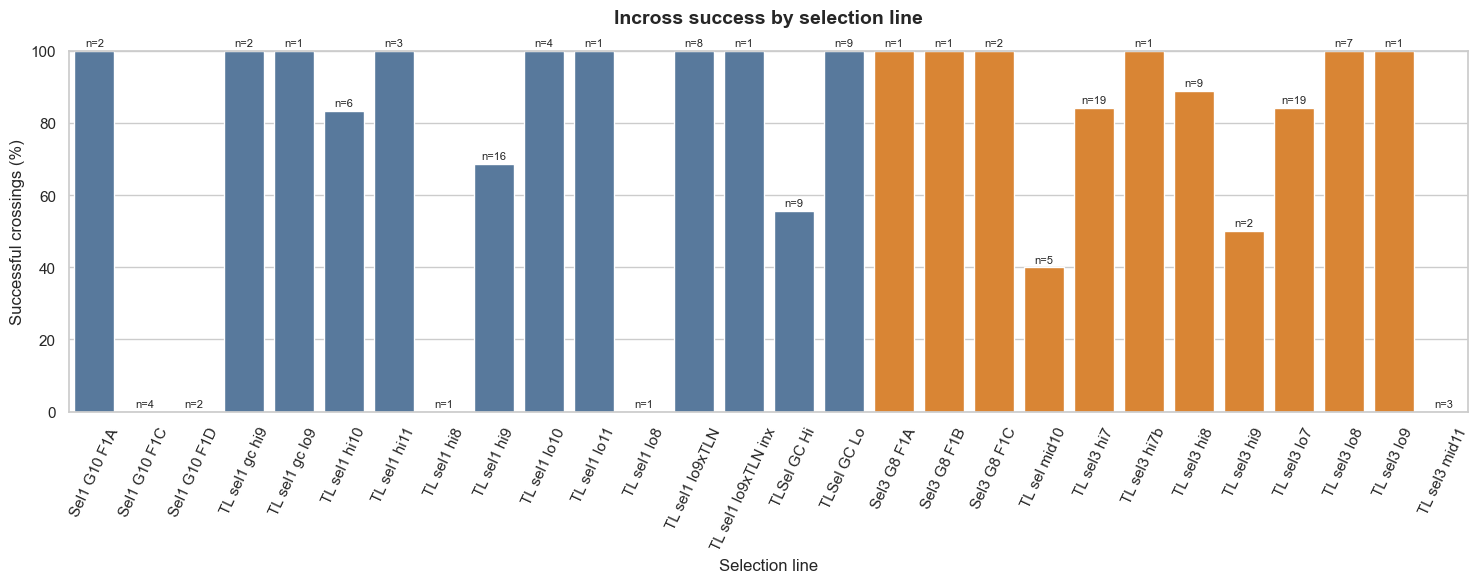

In [39]:

# Convert the male and female parent columns into one line-level table.
# Column positions are used here because the Excel sex symbols are inconsistently encoded.
male_tank_column, male_line_column = crosses_efficiency.columns[[1, 2]]
female_tank_column, female_line_column = crosses_efficiency.columns[[7, 8]]
cross_number_column = crosses_efficiency.columns[0]
# Stack the male and female records vertically so one row represents one line on one cross.
line_crossings = pd.concat(
    [
        selection_crosses_efficiency[[cross_number_column, male_line_column, "successful?"]].rename(
            columns={male_line_column: "line_name"}
        ),
        selection_crosses_efficiency[[cross_number_column, female_line_column, "successful?"]].rename(
            columns={female_line_column: "line_name"}
        ),
    ],
    ignore_index=True,
).dropna(subset=["line_name"])
# Convert names to strings and remove accidental spaces before filtering.
line_crossings["line_name"] = line_crossings["line_name"].astype("string").str.strip()
line_crossings = line_crossings[line_crossings["line_name"].str.contains(SELECTION_LINE_TOKEN, case=False, na=False)]
# A cross can list the same line for both parents; count that cross once per line.
line_crossings = line_crossings.drop_duplicates([cross_number_column, "line_name"])

# Treat entries such as "0 (only males)" as zero; leave blank outcomes out of calculations.
line_crossings["success_value"] = (
    line_crossings["successful?"].astype("string").str.extract(r"^(0|1)", expand=False).astype("Float64")
)
line_crossings = line_crossings.dropna(subset=["success_value"])

# Map each line to the broad family used for plot colours and marker shapes.
def selection_family(line_name):
    compact_name = re.sub(r"\s+", "", line_name.casefold())
    if "sel1" in compact_name or "tlselgc" in compact_name:
        return "sel1"
    if "sel3" in compact_name or "tlselmid" in compact_name:
        return "sel3"
    return pd.NA

# Apply the family rule to every line and fail loudly if a new name is unfamiliar.
line_crossings["family"] = line_crossings["line_name"].map(selection_family)
unmapped_lines = line_crossings.loc[line_crossings["family"].isna(), "line_name"].unique().tolist()
if unmapped_lines:
    raise ValueError(f"Selection lines could not be assigned to sel1 or sel3: {unmapped_lines}")

# Categorical order controls the order of bars and the family legend.
family_order = ["sel1", "sel3"]
# Count all usable crossings and the subset marked successful for each line.
line_success_summary = (
    line_crossings.groupby(["family", "line_name"], as_index=False, observed=True)
    .agg(crossings=("success_value", "size"), successful_crossings=("success_value", "sum"))
)
# Convert counts into the percentage shown by the bar heights.
line_success_summary["success_percentage"] = (
    100 * line_success_summary["successful_crossings"] / line_success_summary["crossings"]
)
line_success_summary["family"] = pd.Categorical(
    line_success_summary["family"], categories=family_order, ordered=True
)
line_success_summary = line_success_summary.sort_values(["family", "line_name"], ignore_index=True)
line_order = line_success_summary["line_name"].tolist()
# Display the table that supplies the barplot.
display(line_success_summary)

# Use a readable grid style and create one wide figure for the rotated line labels.
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 6))
# Seaborn calculates one bar per line from the success percentage column.
sns.barplot(
    data=line_success_summary,
    x="line_name",
    y="success_percentage",
    hue="family",
    hue_order=family_order,
    order=line_order,
    dodge=False,
    palette={"sel1": "#4C78A8", "sel3": "#F58518"},
    legend=False,
    ax=ax,
)
# Set axis labels and keep percentages on the 0-100 scale.
ax.set(
    xlabel="Selection line",
    ylabel="Successful crossings (%)",
    ylim=(0, 100),
)
ax.set_title(f"Incross success by selection line",
             pad=20, fontsize=14, fontweight="bold"
             )
# Rotate long line names so they do not overlap.
ax.tick_params(axis="x", rotation=65)
# Add the sample size (n) above each bar; it is not the percentage itself.
for container, family in zip(ax.containers, family_order):
    sample_sizes = (
        line_success_summary.loc[line_success_summary["family"].eq(family), "crossings"]
        .astype(int)
        .map(lambda count: f"n={count}")
    )
    ax.bar_label(container, labels=sample_sizes, padding=2, fontsize=8)
fig.tight_layout()
plt.show()

## Crossing success by outcome

Each point represents one tank in one selection-line incross. Cross outcomes are binary (0 = failed, 1 = successful).

In [40]:
# numpy supplies reproducible random jitter so overlapping points can be seen.
import numpy as np

# Identify the date, type, birthdate, and parent-role columns by position.
cross_date_column = crosses_efficiency.columns[14]
crossing_type_column = crosses_efficiency.columns[15]
male_birthdate_column = crosses_efficiency.columns[5]
female_birthdate_column = crosses_efficiency.columns[11]

# Expand both parental roles so intervals follow each tank across every recorded cross type.
# This full history is built before applying the selection-line or date filters.
tank_crossings = pd.concat(
    [
        crosses_efficiency[
            [
                cross_number_column,
                male_tank_column,
                male_line_column,
                male_birthdate_column,
                cross_date_column,
                crossing_type_column,
                "successful?",
            ]
        ].rename(
            columns={
                male_tank_column: "tank_id",
                male_line_column: "line_name",
                male_birthdate_column: "birthdate",
                cross_date_column: "cross_date",
                crossing_type_column: "crossing_type",
            }
        ),
        crosses_efficiency[
            [
                cross_number_column,
                female_tank_column,
                female_line_column,
                female_birthdate_column,
                cross_date_column,
                crossing_type_column,
                "successful?",
            ]
        ].rename(
            columns={
                female_tank_column: "tank_id",
                female_line_column: "line_name",
                female_birthdate_column: "birthdate",
                cross_date_column: "cross_date",
                crossing_type_column: "crossing_type",
            }
        ),
    ],
    ignore_index=True,
).dropna(subset=["tank_id"])
# Standardize IDs and line names so matching is not affected by spaces or capitalization.
tank_crossings["tank_id"] = tank_crossings["tank_id"].astype("string").str.strip().str.upper()
tank_crossings["line_name"] = tank_crossings["line_name"].astype("string").str.strip()
# Convert Excel date values to pandas dates; invalid or missing dates become NaT.
tank_crossings["cross_date"] = pd.to_datetime(tank_crossings["cross_date"], errors="coerce")
tank_crossings["birthdate"] = pd.to_datetime(
    tank_crossings["birthdate"], errors="coerce", format="mixed"
)
# Read the first 0 or 1 from the outcome text and treat blanks as missing.
tank_crossings["success_value"] = (
    tank_crossings["successful?"].astype("string").str.extract(r"^(0|1)", expand=False).astype("Float64")
)
# Remove rows without event dates, collapse a tank listed twice on one cross, and sort history.
tank_crossings = (
    tank_crossings.dropna(subset=["cross_date"])
    .drop_duplicates([cross_number_column, "tank_id"])
    .sort_values(["tank_id", "cross_date", cross_number_column], ignore_index=True)
)
# diff() compares each cross with the preceding cross for that same tank.
tank_crossings["days_since_previous_cross"] = (
    tank_crossings.groupby("tank_id", observed=True)["cross_date"].diff().dt.days
)
# Age is the number of whole days between fertilization and the crossing event.
tank_crossings["age_days"] = (tank_crossings["cross_date"] - tank_crossings["birthdate"]).dt.days

# Now select the plotted events. The previous-cross interval above still uses full history.
analysis_crossings = tank_crossings.loc[
    tank_crossings["line_name"].str.contains(SELECTION_LINE_TOKEN, case=False, na=False)
    & tank_crossings["crossing_type"].astype("string").str.strip().str.casefold().eq(
        CROSSING_TYPE_FILTER.strip().casefold()
    )
    # Apply the date window to plotted crossing events, after intervals were calculated.
    & crossing_date_filter(tank_crossings["cross_date"])
].copy()
# Assign family labels so the plots can use a different marker for each family.
analysis_crossings["family"] = analysis_crossings["line_name"].map(selection_family)
unmapped_analysis_lines = analysis_crossings.loc[
    analysis_crossings["family"].isna(), "line_name"
].unique().tolist()
if unmapped_analysis_lines:
    raise ValueError(f"Selection lines could not be assigned to sel1 or sel3: {unmapped_analysis_lines}")
# Negative values indicate inconsistent source dates and should stop the analysis.
if analysis_crossings["age_days"].dropna().lt(0).any():
    raise ValueError("At least one crossing date precedes its tank's fertilization date.")
if analysis_crossings["days_since_previous_cross"].dropna().lt(0).any():
    raise ValueError("At least one previous-cross interval is negative.")

# Each plot drops only rows missing the variable that plot needs or its outcome.
age_crossings = analysis_crossings.dropna(subset=["age_days", "success_value"]).copy()
interval_crossings = analysis_crossings.dropna(
    subset=["days_since_previous_cross", "success_value"]
).copy()
# Keep line colours stable across both outcome plots.
analysis_line_order = (
    analysis_crossings[["family", "line_name"]]
    .drop_duplicates()
    .sort_values(["family", "line_name"])["line_name"]
    .tolist()
)
# Generate one distinct colour per line and define the two family marker shapes.
line_palette = dict(
    zip(analysis_line_order, sns.color_palette("husl", n_colors=len(analysis_line_order)))
)
family_markers = {"sel1": "o", "sel3": "s"}

# Show sample sizes and ranges as a quick check before plotting.
analysis_sample_summary = pd.DataFrame(
    [
        {
            "analysis": "Age at crossing",
            "observations": len(age_crossings),
            "minimum_days": age_crossings["age_days"].min(),
            "maximum_days": age_crossings["age_days"].max(),
        },
        {
            "analysis": "Time since previous cross",
            "observations": len(interval_crossings),
            "minimum_days": interval_crossings["days_since_previous_cross"].min(),
            "maximum_days": interval_crossings["days_since_previous_cross"].max(),
        },
    ]
)
display(analysis_sample_summary)

,analysis,observations,minimum_days,maximum_days
0,Age at crossing,126,71.0,419.0
1,Time since previous cross,79,0.0,163.0


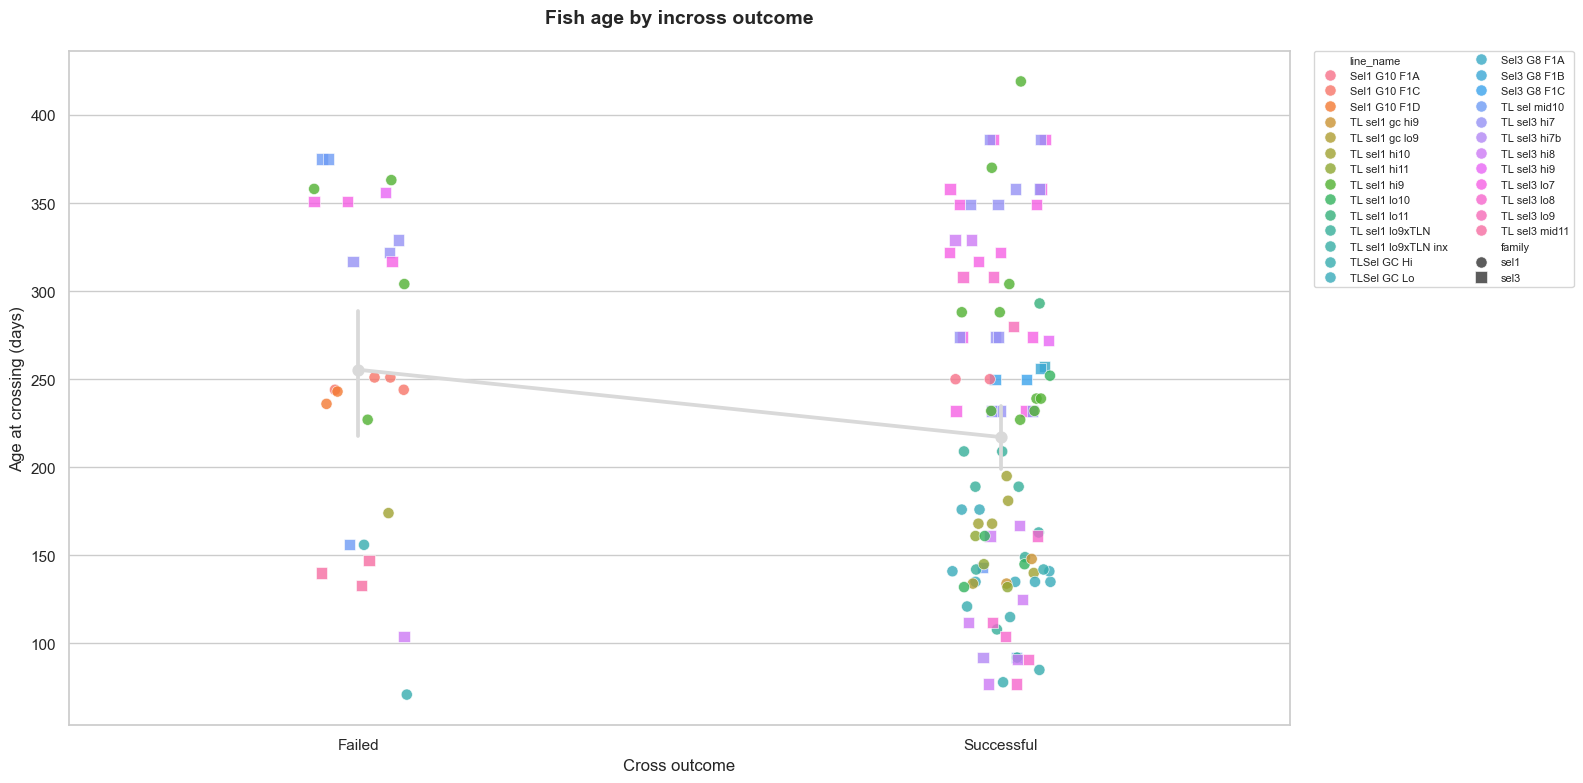

In [41]:
# Make a plotting copy so display jitter does not change the analysis values.
age_plot_data = age_crossings.copy()
age_plot_data["cross_outcome"] = age_plot_data["success_value"].astype(int)
# Add small, repeatable horizontal jitter so overlapping points remain visible.
age_plot_data["display_outcome"] = age_plot_data["cross_outcome"] + (
    np.random.default_rng(20260716).uniform(-0.08, 0.08, len(age_plot_data))
)
age_line_order = [
    line_name for line_name in analysis_line_order if line_name in set(age_plot_data["line_name"])
]

# Create the figure and draw the outcome summary before adding individual points.
fig, ax = plt.subplots(figsize=(16, 8))
# The pointplot summarizes the age distribution for failed and successful outcomes.
sns.pointplot(
    data=age_plot_data,
    x="cross_outcome",
    y="age_days",
    order=[0, 1],
    color="#D9D9D9",
    ax=ax,
)
# Overlay every observation, using colour for line and marker shape for family.
sns.scatterplot(
    data=age_plot_data,
    x="display_outcome",
    y="age_days",
    hue="line_name",
    hue_order=age_line_order,
    style="family",
    style_order=family_order,
    palette=line_palette,
    markers=family_markers,
    s=65,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)
# Put the outcome labels on the x-axis and age in days on the y-axis.
ax.set(
    xlabel="Cross outcome",
    ylabel="Age at crossing (days)",
    xticks=[0, 1],
    xticklabels=["Failed", "Successful"],
    xlim=(-0.45, 1.45),
)
ax.set_title("Fish age by incross outcome", pad=20, fontsize=14, fontweight="bold")
# Place the long line legend outside the plotting area.
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    ncols=2,
    fontsize=8,
    title=None,
)
# Tight layout prevents labels from being cut off when the notebook renders.
fig.tight_layout()
plt.show()

Age-bin analysis: 126 included unique crosses; 0 excluded for multiple parent ages; 0 excluded for multiple lines.


,age_class_months,total_crosses,failed_crosses,failure_proportion
0,2-3,5,1,0.2
1,3-4,11,1,0.090909
2,4-5,23,3,0.130435
3,5-6,13,3,0.230769
4,6-7,6,0,0.0
5,7-8,12,2,0.166667
6,8-9,12,5,0.416667
7,9-10,10,0,0.0
8,10-11,13,5,0.384615
9,11-12,12,4,0.333333


,age_class_months,failure_group,total_crosses,group_failed_crosses,bar_contribution
0,10-11,All selection lines,13,5,0.384615
1,11-12,All selection lines,12,4,0.333333
2,12-13,All selection lines,8,3,0.375
3,2-3,All selection lines,5,1,0.2
4,3-4,All selection lines,11,1,0.090909
5,4-5,All selection lines,23,3,0.130435
6,5-6,All selection lines,13,3,0.230769
7,7-8,All selection lines,12,2,0.166667
8,8-9,All selection lines,12,5,0.416667


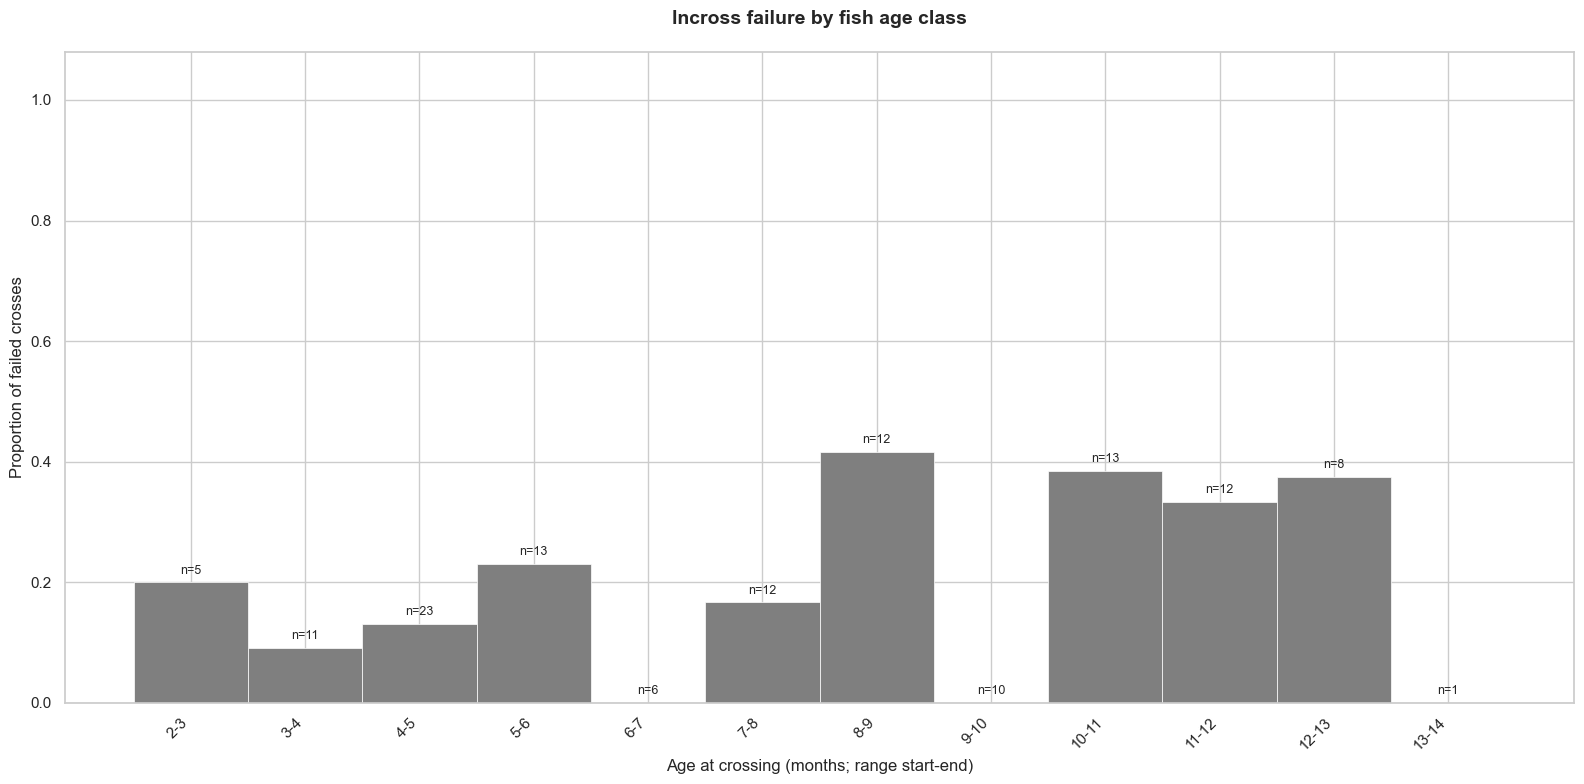

In [42]:
import warnings

# Validate the user-editable bin width before building the cross-level summary.
if isinstance(AGE_BIN_MONTHS, bool):
    raise ValueError("AGE_BIN_MONTHS must be a positive number.")
try:
    age_bin_months = float(AGE_BIN_MONTHS)
except (TypeError, ValueError) as error:
    raise ValueError("AGE_BIN_MONTHS must be a positive number.") from error
if not np.isfinite(age_bin_months) or age_bin_months <= 0:
    raise ValueError("AGE_BIN_MONTHS must be a positive number.")
age_bin_days = 30 * age_bin_months

# Check every selected parent record before reducing the data to one row per cross.
cross_age_candidates = analysis_crossings.dropna(subset=["success_value"]).copy()
cross_age_checks = (
    cross_age_candidates.groupby(cross_number_column, as_index=False, observed=True)
    .agg(
        distinct_parent_ages=("age_days", "nunique"),
        distinct_lines=("line_name", "nunique"),
        distinct_outcomes=("success_value", "nunique"),
    )
)
if cross_age_checks["distinct_outcomes"].gt(1).any():
    inconsistent_crosses = cross_age_checks.loc[
        cross_age_checks["distinct_outcomes"].gt(1), cross_number_column
    ].tolist()
    raise ValueError(f"Crosses have conflicting success outcomes: {inconsistent_crosses}")

# Keep crosses with one known age and one line; either ambiguity would double-count a cross.
eligible_cross_ids = cross_age_checks.loc[
    cross_age_checks["distinct_parent_ages"].eq(1)
    & cross_age_checks["distinct_lines"].eq(1),
    cross_number_column,
]
multi_age_cross_count = int(cross_age_checks["distinct_parent_ages"].gt(1).sum())
multi_line_cross_count = int(cross_age_checks["distinct_lines"].gt(1).sum())
cross_age_data = (
    cross_age_candidates.loc[
        cross_age_candidates[cross_number_column].isin(eligible_cross_ids)
    ]
    .dropna(subset=["age_days"])
    .groupby(cross_number_column, as_index=False, observed=True)
    .agg(
        age_days=("age_days", "first"),
        line_name=("line_name", "first"),
        success_value=("success_value", "first"),
    )
)
if cross_age_data.empty:
    raise ValueError("No crosses have one usable parent age for the age-bin analysis.")
if cross_age_data[cross_number_column].duplicated().any():
    raise AssertionError("Each cross must contribute at most once to the age-bin analysis.")

# Validate the display mode before calculating mode-specific age-bin denominators.
if not isinstance(INCROSS_FAILURE_COLOR_BY, str):
    raise ValueError('INCROSS_FAILURE_COLOR_BY must be "lineage", "line", or "none".')
failure_color_by = INCROSS_FAILURE_COLOR_BY.strip().casefold()
if failure_color_by not in {"lineage", "line", "none"}:
    raise ValueError('INCROSS_FAILURE_COLOR_BY must be "lineage", "line", or "none".')

if failure_color_by == "lineage":
    # Reverse the editable ancestry groups and reject ambiguous assignments.
    lineage_lookup = {}
    duplicate_lineage_lines = []
    for lineage_name, lineage_lines in LINEAGE_GROUPS.items():
        for line_name in lineage_lines:
            normalized_line = line_name.strip().casefold()
            if normalized_line in lineage_lookup:
                duplicate_lineage_lines.append(line_name)
            else:
                lineage_lookup[normalized_line] = lineage_name
    if duplicate_lineage_lines:
        raise ValueError(
            f"Selection lines assigned to multiple lineages: {duplicate_lineage_lines}"
        )

    mapped_lineages = cross_age_data["line_name"].map(
        lambda line_name: lineage_lookup.get(line_name.strip().casefold(), pd.NA)
    )
    unmapped_lineage_mask = mapped_lineages.isna()
    unmapped_lineage_lines = sorted(
        cross_age_data.loc[unmapped_lineage_mask, "line_name"].unique(),
        key=str.casefold,
    )
    if unmapped_lineage_lines:
        unmapped_cross_count = int(unmapped_lineage_mask.sum())
        cross_word = "cross" if unmapped_cross_count == 1 else "crosses"
        line_word = "line" if len(unmapped_lineage_lines) == 1 else "lines"
        warnings.warn(
            f"Lineage analysis excluded {unmapped_cross_count} eligible {cross_word} from "
            f"selection {line_word} missing from LINEAGE_GROUPS: {unmapped_lineage_lines}",
            UserWarning,
            stacklevel=2,
        )
        cross_age_data = cross_age_data.loc[~unmapped_lineage_mask].copy()
        mapped_lineages = mapped_lineages.loc[~unmapped_lineage_mask]
    if cross_age_data.empty:
        raise ValueError(
            "No eligible crosses remain after excluding lines missing from LINEAGE_GROUPS."
        )
    cross_age_data["failure_group"] = mapped_lineages
    failure_group_order = list(LINEAGE_GROUPS)
    failure_group_palette = dict(
        zip(
            failure_group_order,
            sns.color_palette("colorblind", n_colors=len(failure_group_order)),
        )
    )
    failure_legend_title = "Lineage"
elif failure_color_by == "line":
    # Line mode remains independent of the optional lineage mapping.
    cross_age_data["failure_group"] = cross_age_data["line_name"]
    failure_group_order = analysis_line_order
    failure_group_palette = line_palette
    failure_legend_title = "Selection line"
else:
    # Uncoloured mode pools all eligible lines into one neutral bar with no legend.
    uncoloured_group = "All selection lines"
    cross_age_data["failure_group"] = uncoloured_group
    failure_group_order = [uncoloured_group]
    failure_group_palette = {uncoloured_group: "#7F7F7F"}
    failure_legend_title = None
print(
    f"Age-bin analysis: {len(cross_age_data)} included unique crosses; "
    f"{multi_age_cross_count} excluded for multiple parent ages; "
    f"{multi_line_cross_count} excluded for multiple lines."
)

# Anchor bins to multiples of the configured 30-day month width.
minimum_age = cross_age_data["age_days"].min()
maximum_age = cross_age_data["age_days"].max()
first_bin_edge = np.floor(minimum_age / age_bin_days) * age_bin_days
last_bin_edge = (np.floor(maximum_age / age_bin_days) + 1) * age_bin_days
age_bin_edges = np.arange(
    first_bin_edge, last_bin_edge + 0.5 * age_bin_days, age_bin_days
)
cross_age_data["age_bin"] = pd.cut(
    cross_age_data["age_days"], bins=age_bin_edges, right=False, include_lowest=True
)

# observed=True omits empty age classes instead of showing them as zero-success bars.
age_bin_failure_summary = (
    cross_age_data.groupby("age_bin", as_index=False, observed=True)
    .agg(
        total_crosses=("success_value", "size"),
        failed_crosses=("success_value", lambda values: values.eq(0).sum()),
        failure_proportion=("success_value", lambda values: values.eq(0).mean()),
    )
)
age_bin_failure_summary["failed_crosses"] = (
    age_bin_failure_summary["failed_crosses"].astype(int)
)
age_bin_failure_summary["age_start_months"] = (
    age_bin_failure_summary["age_bin"].map(lambda interval: interval.left).astype(float) / 30
)
age_bin_failure_summary["age_end_months"] = (
    age_bin_failure_summary["age_bin"].map(lambda interval: interval.right).astype(float) / 30
)
age_bin_failure_summary["age_class_months"] = age_bin_failure_summary.apply(
    lambda row: f"{row['age_start_months']:g}-{row['age_end_months']:g}", axis=1
)
display(
    age_bin_failure_summary[
        [
            "age_class_months",
            "total_crosses",
            "failed_crosses",
            "failure_proportion",
        ]
    ]
)

# Split failed crosses by the active group, using all age-bin attempts as denominator.
age_group_failure_summary = (
    cross_age_data.loc[cross_age_data["success_value"].eq(0)]
    .groupby(["age_bin", "failure_group"], as_index=False, observed=True)
    .agg(group_failed_crosses=("success_value", "size"))
    .merge(
        age_bin_failure_summary[["age_bin", "total_crosses", "age_class_months"]],
        on="age_bin",
        how="left",
        validate="many_to_one",
    )
)
age_group_failure_summary["bar_contribution"] = (
    age_group_failure_summary["group_failed_crosses"]
    / age_group_failure_summary["total_crosses"]
)
display(
    age_group_failure_summary[
        [
            "age_class_months",
            "failure_group",
            "total_crosses",
            "group_failed_crosses",
            "bar_contribution",
        ]
    ].sort_values(["age_class_months", "failure_group"], ignore_index=True)
)

# Prepare one contribution column per represented group in the configured order.
represented_failure_groups = set(age_group_failure_summary["failure_group"])
stack_group_order = [
    group_name
    for group_name in failure_group_order
    if group_name in represented_failure_groups
]
stack_values = (
    age_group_failure_summary.pivot(
        index="age_class_months", columns="failure_group", values="bar_contribution"
    )
    .reindex(
        index=age_bin_failure_summary["age_class_months"],
        columns=stack_group_order,
        fill_value=0,
    )
    .fillna(0)
)

# Draw one full-width stacked bar per populated age class.
fig, ax = plt.subplots(figsize=(16, 8))
bar_left_edges = age_bin_failure_summary["age_start_months"].to_numpy()
bar_bottoms = np.zeros(len(age_bin_failure_summary), dtype=float)
for group_name in stack_group_order:
    group_heights = stack_values[group_name].to_numpy(dtype=float)
    ax.bar(
        bar_left_edges,
        group_heights,
        width=age_bin_months,
        bottom=bar_bottoms,
        align="edge",
        color=failure_group_palette[group_name],
        edgecolor="white",
        linewidth=0.5,
        label=group_name,
    )
    bar_bottoms += group_heights
age_bin_midpoints = (
    age_bin_failure_summary["age_start_months"] + age_bin_months / 2
)
# Label each bar with every eligible cross attempt in that age class.
for midpoint, bar_height, total_crosses in zip(
    age_bin_midpoints,
    age_bin_failure_summary["failure_proportion"],
    age_bin_failure_summary["total_crosses"],
):
    ax.annotate(
        f"n={int(total_crosses)}",
        xy=(midpoint, float(bar_height)),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_xticks(age_bin_midpoints)
ax.set_xticklabels(age_bin_failure_summary["age_class_months"], rotation=45, ha="right")
ax.set(
    xlabel="Age at crossing (months; range start-end)",
    ylabel="Proportion of failed crosses",
    ylim=(0, 1.08),
)
ax.set_title(
    "Incross failure by fish age class", pad=20, fontsize=14, fontweight="bold"
)
if stack_group_order and failure_legend_title is not None:
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        ncols=2,
        fontsize=8,
        title=failure_legend_title,
    )
fig.tight_layout()
plt.show()

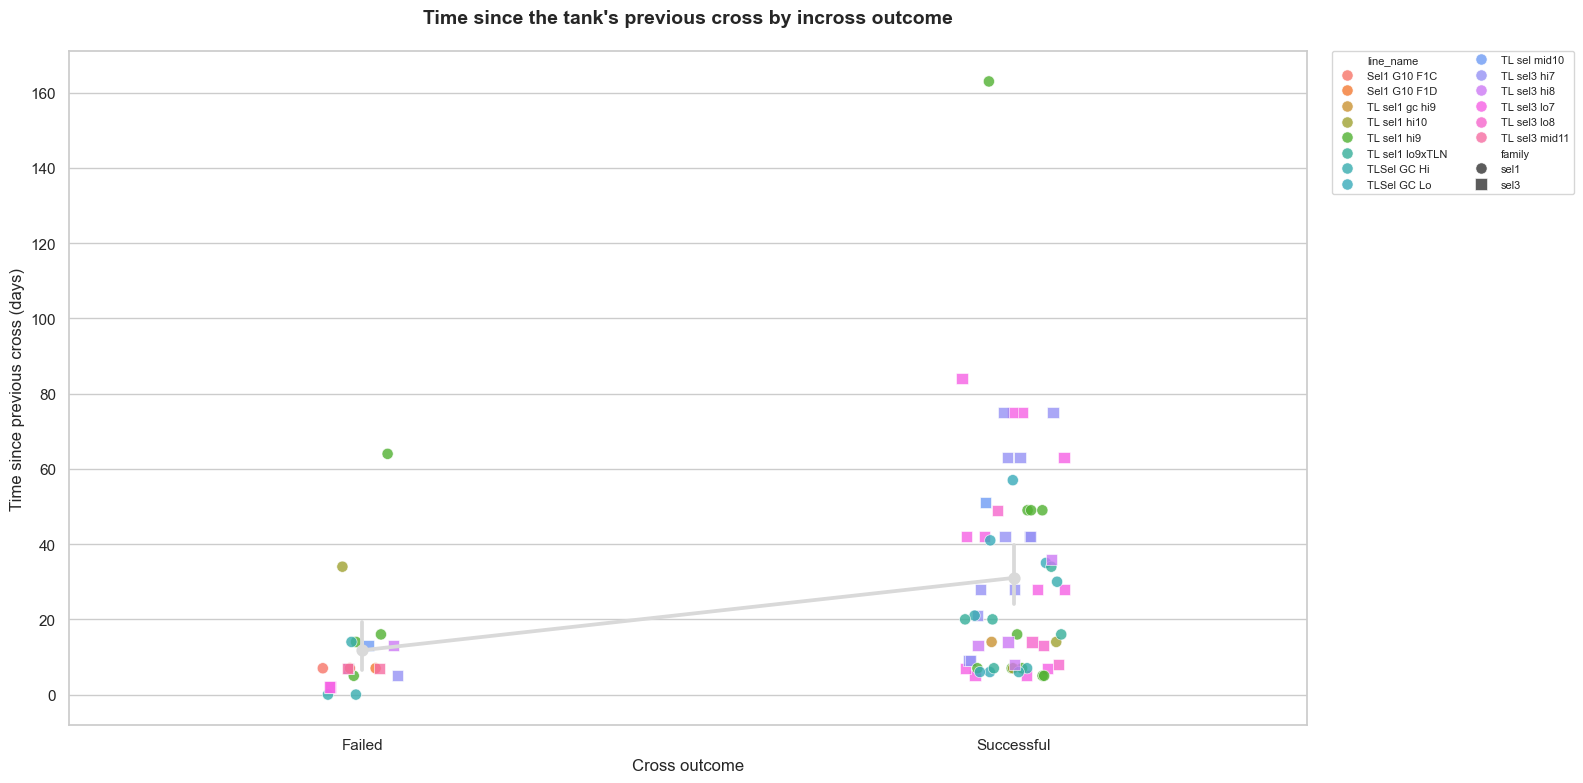

In [43]:
# Use a plotting copy; the jitter below is only for display.
interval_plot_data = interval_crossings.copy()
interval_plot_data["cross_outcome"] = interval_plot_data["success_value"].astype(int)
# Add deterministic horizontal jitter so points at the same outcome do not hide one another.
interval_plot_data["display_outcome"] = interval_plot_data["cross_outcome"] + (
    np.random.default_rng(20260717).uniform(-0.08, 0.08, len(interval_plot_data))
)
interval_line_order = [
    line_name
    for line_name in analysis_line_order
    if line_name in set(interval_plot_data["line_name"])
]

# Create the second figure and summarize waiting times by outcome.
fig, ax = plt.subplots(figsize=(16, 8))
# The pointplot summarizes time since the previous cross for each outcome.
sns.pointplot(
    data=interval_plot_data,
    x="cross_outcome",
    y="days_since_previous_cross",
    order=[0, 1],
    color="#D9D9D9",
    #width=0.5,
    #showfliers=False,
    ax=ax,
)
# Overlay the individual tank-cross observations with the same encodings as above.
sns.scatterplot(
    data=interval_plot_data,
    x="display_outcome",
    y="days_since_previous_cross",
    hue="line_name",
    hue_order=interval_line_order,
    style="family",
    style_order=family_order,
    palette=line_palette,
    markers=family_markers,
    s=65,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)
# Label the x-axis by outcome and the y-axis in elapsed days.
ax.set(
    xlabel="Cross outcome",
    ylabel="Time since previous cross (days)",
    xticks=[0, 1],
    xticklabels=["Failed", "Successful"],
    xlim=(-0.45, 1.45),
)
ax.set_title(
    "Time since the tank's previous cross by incross outcome",
    pad=20,
    fontsize=14,
    fontweight="bold",
)
# Keep the legend outside the axes so it does not cover data points.
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    ncols=2,
    fontsize=8,
    title=None,
)
# Adjust spacing for notebook display.
fig.tight_layout()
plt.show()

## Mortality by age

Filter the fish-moves worksheet to selection lines, then compare the age distributions of fish sacrificed for overall bad shape and fish found dead.

In [44]:
import warnings

# Load the fish-moves worksheet. header=4 means the real column names are on row 5.
fish_moves = pd.read_excel(
    WORKBOOK_PATHS["fish_database.xlsx"],
    sheet_name="Fish moves",
    header=4,
)

# Standardize the filter columns so capitalization and extra spaces do not change matches.
fish_move_lines = fish_moves["Line"].astype("string").str.strip()
fish_move_types = fish_moves["Move type"].astype("string").str.strip().str.casefold()
fish_move_reasons = fish_moves["Main reason"].astype("string").str.strip().str.casefold()
selection_move_mask = fish_move_lines.str.contains(
    SELECTION_LINE_TOKEN, case=False, na=False
)
bad_shape_mask = (
    fish_move_types.eq("sacrifice")
    & fish_move_reasons.eq("overall bad shape")
)
found_dead_mask = fish_move_types.eq("found dead")

# Each retained worksheet row is one observation in the mortality histograms.
mortality_events = fish_moves.loc[
    selection_move_mask & (bad_shape_mask | found_dead_mask),
    ["Date", "Tank", "Line", "Age [months]", "Move type", "Main reason"],
].copy()
mortality_events["line_name"] = mortality_events["Line"].astype("string").str.strip()
mortality_events["mortality_category"] = "Overall bad shape"
mortality_events.loc[
    fish_move_types.loc[mortality_events.index].eq("found dead"),
    "mortality_category",
] = "Found dead"
mortality_events["age_months"] = pd.to_numeric(
    mortality_events["Age [months]"], errors="coerce"
)
missing_mortality_ages = int(mortality_events["age_months"].isna().sum())
mortality_events = mortality_events.dropna(subset=["age_months"]).copy()
if mortality_events.empty:
    raise ValueError("No matching selection-line mortality records have a usable age.")

# Use one shared grouping and palette across both mortality plot families.
if not isinstance(MORTALITY_COLOR_BY, str):
    raise ValueError('MORTALITY_COLOR_BY must be "none", "line", or "lineage".')
mortality_color_by = MORTALITY_COLOR_BY.strip().casefold()
if mortality_color_by not in {"none", "line", "lineage"}:
    raise ValueError('MORTALITY_COLOR_BY must be "none", "line", or "lineage".')
mortality_line_order = sorted(
    mortality_events["line_name"].dropna().unique(), key=str.casefold
)
mortality_line_palette = dict(
    zip(
        mortality_line_order,
        sns.color_palette("husl", n_colors=len(mortality_line_order)),
    )
)
mortality_lineage_lookup = {}
if mortality_color_by == "lineage":
    duplicate_mortality_lineage_lines = []
    for lineage_name, lineage_lines in LINEAGE_GROUPS.items():
        for line_name in lineage_lines:
            normalized_line = line_name.strip().casefold()
            if normalized_line in mortality_lineage_lookup:
                duplicate_mortality_lineage_lines.append(line_name)
            else:
                mortality_lineage_lookup[normalized_line] = lineage_name
    if duplicate_mortality_lineage_lines:
        raise ValueError(
            "Selection lines assigned to multiple mortality lineages: "
            f"{duplicate_mortality_lineage_lines}"
        )
    mapped_event_lineages = mortality_events["line_name"].map(
        lambda line_name: mortality_lineage_lookup.get(line_name.casefold(), pd.NA)
    )
    unmapped_event_mask = mapped_event_lineages.isna()
    unmapped_event_lines = sorted(
        mortality_events.loc[unmapped_event_mask, "line_name"].unique(),
        key=str.casefold,
    )
    if unmapped_event_lines:
        excluded_record_count = int(unmapped_event_mask.sum())
        record_word = "record" if excluded_record_count == 1 else "records"
        line_word = "line" if len(unmapped_event_lines) == 1 else "lines"
        warnings.warn(
            f"Mortality histograms excluded {excluded_record_count} {record_word} from "
            f"selection {line_word} missing from LINEAGE_GROUPS: {unmapped_event_lines}",
            UserWarning,
            stacklevel=2,
        )
        mortality_events = mortality_events.loc[~unmapped_event_mask].copy()
        mapped_event_lineages = mapped_event_lineages.loc[~unmapped_event_mask]
    if mortality_events.empty:
        raise ValueError(
            "No mortality records remain after excluding lines missing from LINEAGE_GROUPS."
        )
    mortality_events["mortality_group"] = mapped_event_lineages
    mortality_group_order = list(LINEAGE_GROUPS)
    mortality_group_palette = dict(
        zip(
            mortality_group_order,
            sns.color_palette("colorblind", n_colors=len(mortality_group_order)),
        )
    )
    mortality_legend_title = "Lineage"
elif mortality_color_by == "line":
    mortality_events["mortality_group"] = mortality_events["line_name"]
    mortality_group_order = mortality_line_order
    mortality_group_palette = mortality_line_palette
    mortality_legend_title = "Selection line"
else:
    mortality_uncoloured_group = "All selection lines"
    mortality_events["mortality_group"] = mortality_uncoloured_group
    mortality_group_order = [mortality_uncoloured_group]
    mortality_group_palette = {mortality_uncoloured_group: "#7F7F7F"}
    mortality_legend_title = None

mortality_category_counts = (
    mortality_events["mortality_category"]
    .value_counts()
    .rename_axis("mortality_category")
    .reset_index(name="records")
)
print(
    f"Mortality analysis: {len(mortality_events)} records with usable ages; "
    f"{missing_mortality_ages} matching records excluded for missing or invalid age."
)
display(mortality_category_counts)

Mortality analysis: 320 records with usable ages; 0 matching records excluded for missing or invalid age.


c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


,mortality_category,records
0,Found dead,208
1,Overall bad shape,112


,mortality_plot,age_class_months,mortality_group,records
0,All mortality records,0-1,All selection lines,110
1,All mortality records,1-2,All selection lines,19
2,All mortality records,2-3,All selection lines,43
3,All mortality records,3-4,All selection lines,17
4,All mortality records,4-5,All selection lines,13
5,All mortality records,5-6,All selection lines,11
6,All mortality records,6-7,All selection lines,8
7,All mortality records,7-8,All selection lines,4
8,All mortality records,8-9,All selection lines,11
9,All mortality records,9-10,All selection lines,13


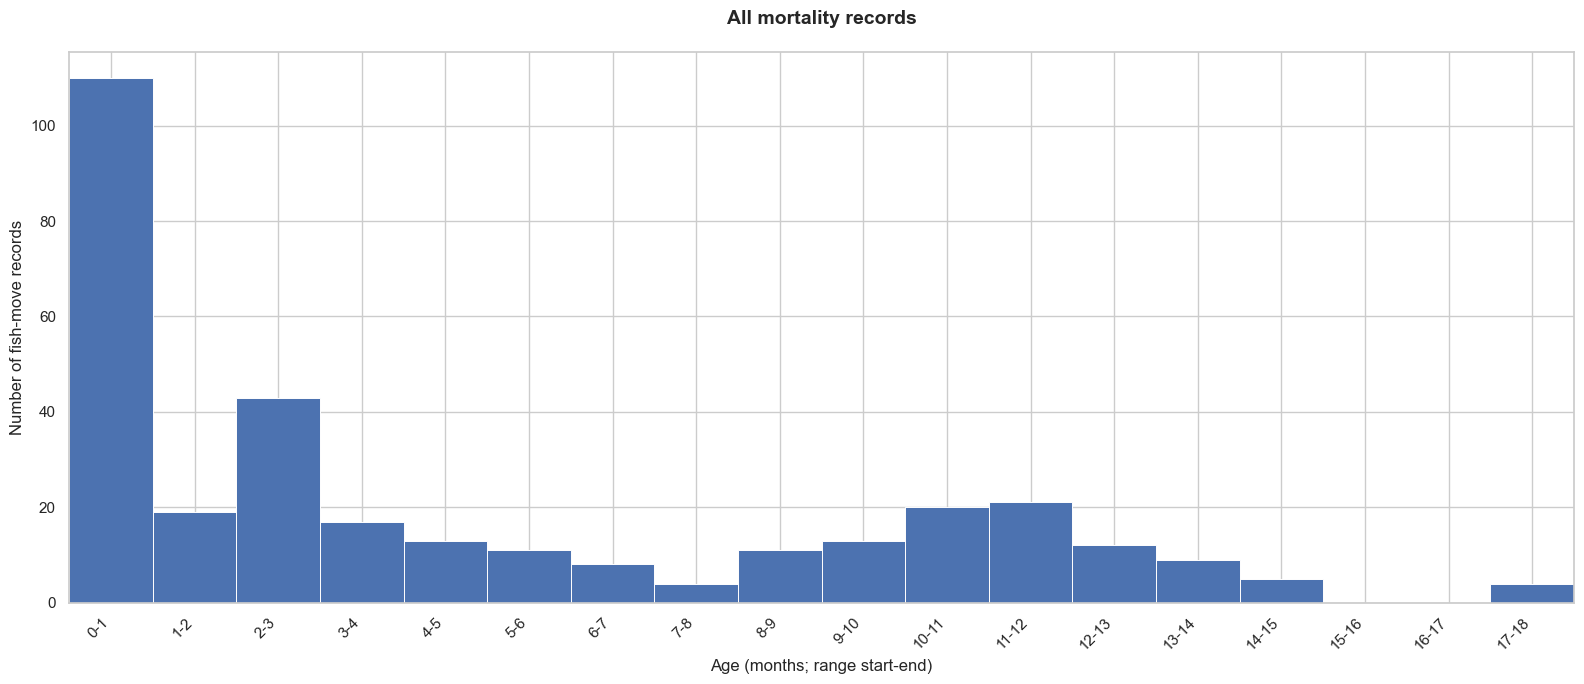

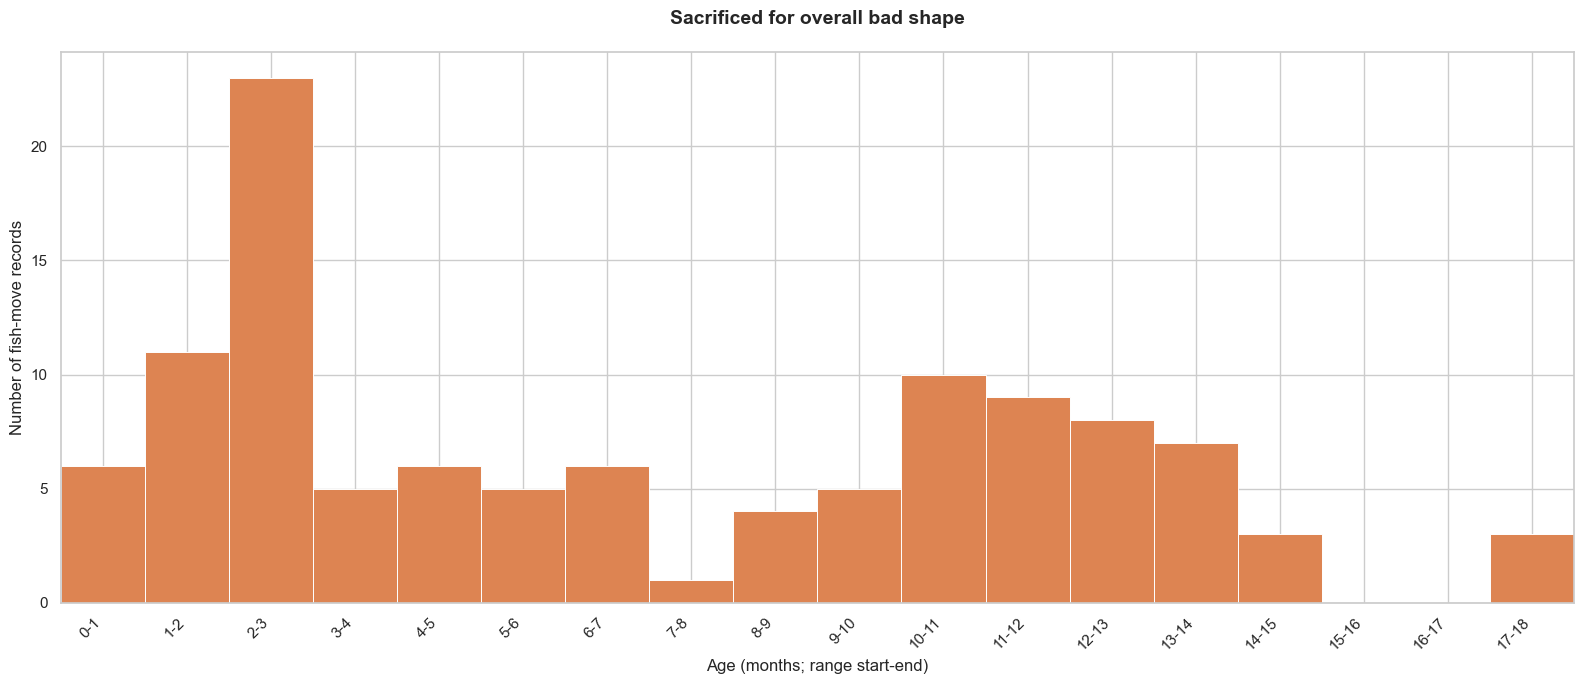

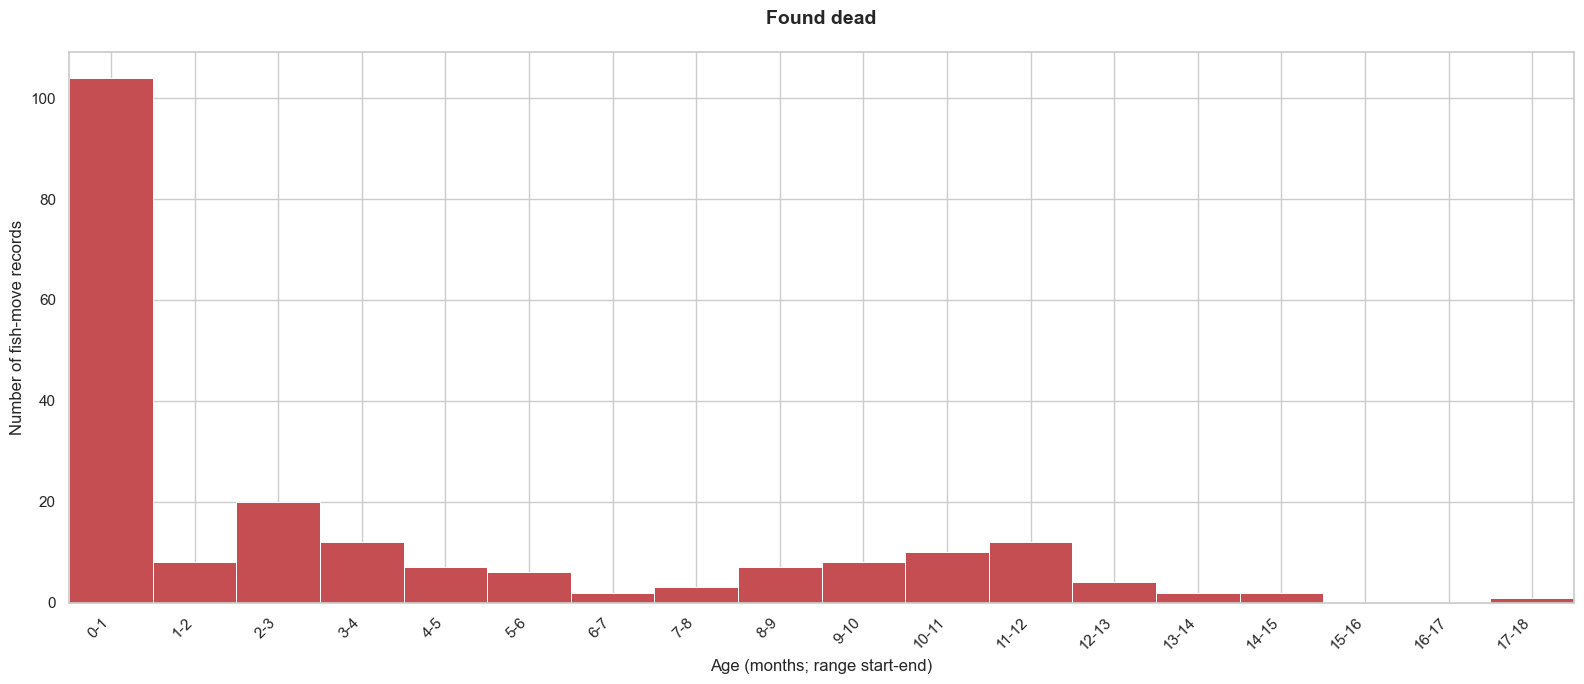

In [45]:
import numpy as np

# Use the crossing analysis setting so both sections have the same month-wide age classes.
if isinstance(AGE_BIN_MONTHS, bool):
    raise ValueError("AGE_BIN_MONTHS must be a positive number.")
try:
    mortality_age_bin_months = float(AGE_BIN_MONTHS)
except (TypeError, ValueError) as error:
    raise ValueError("AGE_BIN_MONTHS must be a positive number.") from error
if not np.isfinite(mortality_age_bin_months) or mortality_age_bin_months <= 0:
    raise ValueError("AGE_BIN_MONTHS must be a positive number.")

# Anchor the shared histogram edges to multiples of the configured month width.
minimum_age_months = mortality_events["age_months"].min()
maximum_age_months = mortality_events["age_months"].max()
first_mortality_bin_edge = (
    np.floor(minimum_age_months / mortality_age_bin_months)
    * mortality_age_bin_months
)
last_mortality_bin_edge = (
    np.floor(maximum_age_months / mortality_age_bin_months) + 1
) * mortality_age_bin_months
mortality_age_bin_edges = np.arange(
    first_mortality_bin_edge,
    last_mortality_bin_edge + 0.5 * mortality_age_bin_months,
    mortality_age_bin_months,
)
mortality_age_bin_midpoints = (
    mortality_age_bin_edges[:-1] + mortality_age_bin_edges[1:]
) / 2
mortality_age_bin_labels = [
    f"{left:g}-{right:g}"
    for left, right in zip(mortality_age_bin_edges[:-1], mortality_age_bin_edges[1:])
]

mortality_age_intervals = pd.IntervalIndex.from_breaks(
    mortality_age_bin_edges, closed="left"
)
mortality_age_label_lookup = dict(zip(mortality_age_intervals, mortality_age_bin_labels))
mortality_events["age_bin"] = pd.cut(
    mortality_events["age_months"],
    bins=mortality_age_bin_edges,
    right=False,
    include_lowest=True,
)

# Summarize the three record-count plots by the active colour group.
mortality_histograms = [
    ("All mortality records", None, "#4C72B0"),
    ("Sacrificed for overall bad shape", "Overall bad shape", "#DD8452"),
    ("Found dead", "Found dead", "#C44E52"),
]
mortality_histogram_group_frames = []
for plot_name, mortality_category, color in mortality_histograms:
    plot_data = (
        mortality_events
        if mortality_category is None
        else mortality_events.loc[
            mortality_events["mortality_category"].eq(mortality_category)
        ]
    )
    group_counts = (
        plot_data.groupby(["age_bin", "mortality_group"], observed=True)
        .size()
        .reset_index(name="records")
    )
    group_counts["mortality_plot"] = plot_name
    group_counts["age_class_months"] = group_counts["age_bin"].map(
        mortality_age_label_lookup
    )
    mortality_histogram_group_frames.append(group_counts)
mortality_histogram_group_summary = pd.concat(
    mortality_histogram_group_frames, ignore_index=True
)
display(
    mortality_histogram_group_summary[
        ["mortality_plot", "age_class_months", "mortality_group", "records"]
    ].sort_values(
        ["mortality_plot", "age_class_months", "mortality_group"],
        ignore_index=True,
    )
)

# Draw stacked group contributions while preserving each histogram's record totals.
for plot_name, mortality_category, color in mortality_histograms:
    plot_summary = mortality_histogram_group_summary.loc[
        mortality_histogram_group_summary["mortality_plot"].eq(plot_name)
    ]
    represented_groups = set(plot_summary["mortality_group"])
    stack_group_order = [
        group_name
        for group_name in mortality_group_order
        if group_name in represented_groups
    ]
    stack_counts = (
        plot_summary.pivot(
            index="age_class_months", columns="mortality_group", values="records"
        )
        .reindex(
            index=mortality_age_bin_labels,
            columns=stack_group_order,
            fill_value=0,
        )
        .fillna(0)
    )
    plot_palette = (
        {mortality_uncoloured_group: color}
        if mortality_color_by == "none"
        else mortality_group_palette
    )
    fig, ax = plt.subplots(figsize=(16, 7))
    bar_bottoms = np.zeros(len(mortality_age_bin_labels), dtype=float)
    for group_name in stack_group_order:
        group_counts = stack_counts[group_name].to_numpy(dtype=float)
        ax.bar(
            mortality_age_bin_edges[:-1],
            group_counts,
            width=mortality_age_bin_months,
            bottom=bar_bottoms,
            align="edge",
            color=plot_palette[group_name],
            edgecolor="white",
            linewidth=0.7,
            label=group_name,
        )
        bar_bottoms += group_counts
    ax.set_xticks(mortality_age_bin_midpoints)
    ax.set_xticklabels(mortality_age_bin_labels, rotation=45, ha="right")
    ax.set(
        xlabel="Age (months; range start-end)",
        ylabel="Number of fish-move records",
        xlim=(mortality_age_bin_edges[0], mortality_age_bin_edges[-1]),
    )
    ax.set_title(plot_name, pad=20, fontsize=14, fontweight="bold")
    if stack_group_order and mortality_legend_title is not None:
        ax.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0,
            ncols=2,
            fontsize=8,
            title=mortality_legend_title,
        )
    fig.tight_layout()
    plt.show()

## Proportion dying by age and tank

Use each tank's initial `Plate` count as its denominator, then average the non-cumulative proportion dying within each age class across tanks that reached that class.

In [46]:
# Load the tank-level initial counts and follow-up ages from the row-5 worksheet header.
mortality_tanks = pd.read_excel(
    WORKBOOK_PATHS["fish_database.xlsx"],
    sheet_name="Tanks",
    header=4,
    usecols=["Tank ID", "Line", "Age [months]", "Plate"],
).rename(
    columns={
        "Tank ID": "tank_id",
        "Line": "line_name",
        "Age [months]": "followup_age_months",
        "Plate": "initial_fish",
    }
)
mortality_tanks["tank_id"] = (
    mortality_tanks["tank_id"].astype("string").str.strip().str.upper()
)
mortality_tanks["line_name"] = mortality_tanks["line_name"].astype("string").str.strip()
all_database_tank_ids = set(mortality_tanks["tank_id"].dropna())
mortality_tanks = mortality_tanks.loc[
    mortality_tanks["line_name"].str.contains(SELECTION_LINE_TOKEN, case=False, na=False)
].copy()
if mortality_tanks["tank_id"].duplicated().any():
    duplicate_tanks = mortality_tanks.loc[
        mortality_tanks["tank_id"].duplicated(keep=False), "tank_id"
    ].unique().tolist()
    raise ValueError(f"Selection tank IDs are not unique in Tanks: {duplicate_tanks}")

# Resolve the editable line filter against the canonical names in the Tanks sheet.
valid_mortality_lines = sorted(mortality_tanks["line_name"].dropna().unique(), key=str.casefold)
valid_line_lookup = {line_name.casefold(): line_name for line_name in valid_mortality_lines}
if isinstance(MORTALITY_LINE_FILTER, str):
    requested_mortality_lines = [MORTALITY_LINE_FILTER]
elif isinstance(MORTALITY_LINE_FILTER, (list, tuple, set)):
    requested_mortality_lines = list(MORTALITY_LINE_FILTER)
else:
    raise ValueError('MORTALITY_LINE_FILTER must be "all", a line name, or a list/tuple/set of line names.')
if not requested_mortality_lines or not all(isinstance(value, str) for value in requested_mortality_lines):
    raise ValueError("MORTALITY_LINE_FILTER must contain at least one line-name string.")
normalized_requested_lines = [value.strip().casefold() for value in requested_mortality_lines]
if any(not value for value in normalized_requested_lines):
    raise ValueError("MORTALITY_LINE_FILTER cannot contain blank line names.")
if "all" in normalized_requested_lines:
    if len(normalized_requested_lines) != 1:
        raise ValueError('Use "all" by itself, not together with explicit line names.')
    selected_mortality_lines = valid_mortality_lines
    mortality_line_label = "all selection lines"
else:
    unknown_lines = [
        requested_mortality_lines[index]
        for index, value in enumerate(normalized_requested_lines)
        if value not in valid_line_lookup
    ]
    if unknown_lines:
        raise ValueError(
            f"Unknown mortality line(s): {unknown_lines}. Valid lines: {valid_mortality_lines}"
        )
    selected_mortality_lines = list(
        dict.fromkeys(valid_line_lookup[value] for value in normalized_requested_lines)
    )
    mortality_line_label = (
        selected_mortality_lines[0]
        if len(selected_mortality_lines) == 1
        else f"{len(selected_mortality_lines)} selected lines"
    )
mortality_tanks = mortality_tanks.loc[
    mortality_tanks["line_name"].isin(selected_mortality_lines)
].copy()

# Plate is used only as the initial denominator; Age is current age or age at closure.
mortality_tanks["initial_fish"] = pd.to_numeric(mortality_tanks["initial_fish"], errors="coerce")
mortality_tanks["followup_age_months"] = pd.to_numeric(
    mortality_tanks["followup_age_months"], errors="coerce"
)
invalid_tank_denominator = mortality_tanks["initial_fish"].isna() | mortality_tanks["initial_fish"].le(0)
invalid_tank_followup = mortality_tanks["followup_age_months"].isna() | mortality_tanks["followup_age_months"].lt(0)
excluded_tank_ids = mortality_tanks.loc[
    invalid_tank_denominator | invalid_tank_followup, "tank_id"
].tolist()
mortality_tanks = mortality_tanks.loc[
    ~(invalid_tank_denominator | invalid_tank_followup)
].copy()
if mortality_tanks.empty:
    raise ValueError("No selected tanks have a positive Plate count and usable follow-up age.")

# Assign the active mortality group before building at-risk denominators.
if mortality_color_by == "lineage":
    mapped_tank_lineages = mortality_tanks["line_name"].map(
        lambda line_name: mortality_lineage_lookup.get(line_name.casefold(), pd.NA)
    )
    unmapped_tank_mask = mapped_tank_lineages.isna()
    unmapped_tank_lines = sorted(
        mortality_tanks.loc[unmapped_tank_mask, "line_name"].unique(),
        key=str.casefold,
    )
    if unmapped_tank_lines:
        excluded_tank_count = int(unmapped_tank_mask.sum())
        tank_word = "tank" if excluded_tank_count == 1 else "tanks"
        line_word = "line" if len(unmapped_tank_lines) == 1 else "lines"
        warnings.warn(
            f"Tank-normalized mortality analysis excluded {excluded_tank_count} {tank_word} "
            f"from selection {line_word} missing from LINEAGE_GROUPS: "
            f"{unmapped_tank_lines}",
            UserWarning,
            stacklevel=2,
        )
        mortality_tanks = mortality_tanks.loc[~unmapped_tank_mask].copy()
        mapped_tank_lineages = mapped_tank_lineages.loc[~unmapped_tank_mask]
    if mortality_tanks.empty:
        raise ValueError(
            "No mortality tanks remain after excluding lines missing from LINEAGE_GROUPS."
        )
    mortality_tanks["mortality_group"] = mapped_tank_lineages
elif mortality_color_by == "line":
    mortality_tanks["mortality_group"] = mortality_tanks["line_name"]
else:
    mortality_tanks["mortality_group"] = mortality_uncoloured_group
mortality_tank_group_lookup = mortality_tanks.set_index("tank_id")["mortality_group"]

# Keep only found-dead events and sacrifices explicitly attributed to overall bad shape.
mortality_amount_columns = ["♀", "♂", "U"]
missing_amount_columns = [column for column in mortality_amount_columns if column not in fish_moves.columns]
if missing_amount_columns:
    raise KeyError(f"Fish moves is missing mortality amount columns: {missing_amount_columns}")
qualifying_mortality_mask = selection_move_mask & (bad_shape_mask | found_dead_mask)
mortality_fish_events = fish_moves.loc[
    qualifying_mortality_mask,
    ["Tank", "Line", "Age [months]", "Move type", "Main reason", *mortality_amount_columns],
].copy()
mortality_amount_source = mortality_fish_events[mortality_amount_columns]
mortality_amounts = mortality_amount_source.apply(pd.to_numeric, errors="coerce")
invalid_amounts = mortality_amount_source.notna() & mortality_amount_source.astype("string").apply(
    lambda column: column.str.strip().ne("")
) & mortality_amounts.isna()
if invalid_amounts.any().any():
    invalid_rows = mortality_fish_events.index[invalid_amounts.any(axis=1)].tolist()
    raise ValueError(f"Mortality amount columns contain nonnumeric values in rows: {invalid_rows}")
mortality_amounts = mortality_amounts.fillna(0)
if mortality_amounts.lt(0).any().any():
    negative_rows = mortality_fish_events.index[mortality_amounts.lt(0).any(axis=1)].tolist()
    raise ValueError(f"Mortality amount columns contain negative values in rows: {negative_rows}")
mortality_fish_events["fish_dying"] = mortality_amounts.sum(axis=1)
mortality_fish_events["tank_id"] = (
    mortality_fish_events["Tank"].astype("string").str.strip().str.upper()
)
mortality_fish_events["age_months"] = pd.to_numeric(
    mortality_fish_events["Age [months]"], errors="coerce"
)
mortality_fish_events["mortality_category"] = "Overall bad shape"
mortality_fish_events.loc[
    fish_move_types.loc[mortality_fish_events.index].eq("found dead"),
    "mortality_category",
] = "Found dead"
missing_event_tanks = sorted(
    set(mortality_fish_events["tank_id"]) - all_database_tank_ids
)
if missing_event_tanks:
    raise ValueError(f"Qualifying mortality events have no Tanks row: {missing_event_tanks}")
mortality_fish_events = mortality_fish_events.loc[
    mortality_fish_events["tank_id"].isin(mortality_tanks["tank_id"])
    & mortality_fish_events["age_months"].notna()
].copy()
mortality_fish_events["mortality_group"] = mortality_fish_events["tank_id"].map(
    mortality_tank_group_lookup
)

# Rebuild shared bins from all qualifying mortality ages so line filters remain comparable.
if isinstance(AGE_BIN_MONTHS, bool):
    raise ValueError("AGE_BIN_MONTHS must be a positive number.")
try:
    mortality_proportion_bin_months = float(AGE_BIN_MONTHS)
except (TypeError, ValueError) as error:
    raise ValueError("AGE_BIN_MONTHS must be a positive number.") from error
if not np.isfinite(mortality_proportion_bin_months) or mortality_proportion_bin_months <= 0:
    raise ValueError("AGE_BIN_MONTHS must be a positive number.")
global_mortality_ages = pd.to_numeric(
    fish_moves.loc[qualifying_mortality_mask, "Age [months]"], errors="coerce"
).dropna()
if global_mortality_ages.empty:
    raise ValueError("No qualifying mortality events have a usable age.")
first_proportion_bin_edge = (
    np.floor(global_mortality_ages.min() / mortality_proportion_bin_months)
    * mortality_proportion_bin_months
)
last_proportion_bin_edge = (
    np.floor(global_mortality_ages.max() / mortality_proportion_bin_months) + 1
) * mortality_proportion_bin_months
mortality_proportion_bin_edges = np.arange(
    first_proportion_bin_edge,
    last_proportion_bin_edge + 0.5 * mortality_proportion_bin_months,
    mortality_proportion_bin_months,
)
mortality_proportion_categories = [
    "All qualifying mortality", "Overall bad shape", "Found dead"
]
mortality_proportion_rows = []
mortality_group_proportion_rows = []
for left_age, right_age in zip(
    mortality_proportion_bin_edges[:-1], mortality_proportion_bin_edges[1:]
):
    age_label = f"{left_age:g}-{right_age:g}"
    at_risk_tanks = mortality_tanks.loc[
        mortality_tanks["followup_age_months"].ge(left_age)
    ].copy()
    if at_risk_tanks.empty:
        continue
    bin_events = mortality_fish_events.loc[
        mortality_fish_events["age_months"].ge(left_age)
        & mortality_fish_events["age_months"].lt(right_age)
    ]
    for mortality_category in mortality_proportion_categories:
        category_events = (
            bin_events
            if mortality_category == "All qualifying mortality"
            else bin_events.loc[bin_events["mortality_category"].eq(mortality_category)]
        )
        deaths_by_tank = category_events.groupby("tank_id", observed=True)["fish_dying"].sum()
        tank_proportion_data = at_risk_tanks[
            ["tank_id", "mortality_group"]
        ].copy()
        tank_proportion_data["tank_proportion_dying"] = (
            at_risk_tanks["tank_id"].map(deaths_by_tank).fillna(0).to_numpy(dtype=float)
            / at_risk_tanks["initial_fish"].to_numpy(dtype=float)
        )
        tank_proportions = tank_proportion_data["tank_proportion_dying"].to_numpy()
        if np.any((tank_proportions < 0) | (tank_proportions > 1)):
            raise ValueError(
                f"Mortality proportions fall outside 0-1 for {mortality_category}, age {age_label}."
            )
        fish_dying_by_group = category_events.groupby(
            "mortality_group", observed=True
        )["fish_dying"].sum()
        for group_name, group_tanks in tank_proportion_data.groupby(
            "mortality_group", observed=True
        ):
            group_tank_ids = group_tanks["tank_id"]
            mortality_group_proportion_rows.append(
                {
                    "mortality_category": mortality_category,
                    "age_start_months": left_age,
                    "age_end_months": right_age,
                    "age_class_months": age_label,
                    "mortality_group": group_name,
                    "tank_count": len(at_risk_tanks),
                    "group_at_risk_tanks": len(group_tanks),
                    "group_tanks_with_deaths": int(
                        group_tank_ids.isin(deaths_by_tank.index).sum()
                    ),
                    "group_fish_dying": float(
                        fish_dying_by_group.get(group_name, 0)
                    ),
                    "mean_proportion_contribution": float(
                        group_tanks["tank_proportion_dying"].sum()
                        / len(at_risk_tanks)
                    ),
                }
            )
        mortality_proportion_rows.append(
            {
                "mortality_category": mortality_category,
                "age_start_months": left_age,
                "age_end_months": right_age,
                "age_class_months": age_label,
                "tank_count": len(at_risk_tanks),
                "tanks_with_deaths": int(at_risk_tanks["tank_id"].isin(deaths_by_tank.index).sum()),
                "fish_dying": float(category_events["fish_dying"].sum()),
                "mean_proportion_dying": float(tank_proportions.mean()),
            }
        )
mortality_proportion_summary = pd.DataFrame(mortality_proportion_rows)
mortality_group_proportion_summary = pd.DataFrame(mortality_group_proportion_rows)
mortality_contribution_check = (
    mortality_group_proportion_summary.groupby(
        ["mortality_category", "age_class_months"], as_index=False, observed=True
    )["mean_proportion_contribution"]
    .sum()
    .merge(
        mortality_proportion_summary[
            ["mortality_category", "age_class_months", "mean_proportion_dying"]
        ],
        on=["mortality_category", "age_class_months"],
        how="outer",
        validate="one_to_one",
    )
)
if not np.allclose(
    mortality_contribution_check["mean_proportion_contribution"],
    mortality_contribution_check["mean_proportion_dying"],
    rtol=1e-10,
    atol=1e-12,
):
    raise AssertionError("Mortality group contributions do not sum to the overall means.")
print(f"Mortality line filter: {selected_mortality_lines}")
print(
    f"Selected tanks with usable Plate/follow-up: {len(mortality_tanks)}; "
    f"excluded selected tanks: {excluded_tank_ids}"
)
display(mortality_proportion_summary)
display(mortality_group_proportion_summary)

Mortality line filter: ['Sel1 G10 F1A', 'Sel1 G10 F1B', 'Sel1 G10 F1C', 'Sel1 G10 F1D', 'sel1 hi10xGC', 'sel3 g7 F1A', 'sel3 g7 F1B', 'Sel3 G8 F1A', 'Sel3 G8 F1B', 'Sel3 G8 F1C', 'Sel3 G8 F1D', 'TL sel mid10', 'TL sel1 gc hi8', 'TL sel1 gc hi9', 'TL sel1 gc lo8', 'TL sel1 gc lo9', 'TL sel1 hi10', 'TL sel1 hi11', 'TL sel1 hi12', 'TL sel1 hi8', 'TL sel1 hi9', 'TL sel1 lo10', 'TL sel1 lo11', 'TL sel1 lo8', 'TL sel1 lo9xTLN', 'TL sel1 lo9xTLN inx', 'TL sel3 hi7', 'TL sel3 hi7b', 'TL sel3 hi8', 'TL sel3 hi9', 'TL sel3 lo7', 'TL sel3 lo8', 'TL sel3 lo9', 'TL sel3 mid11', 'TLSel GC Hi', 'TLSel GC Hi outX Hi5', 'TLSel GC Lo']
Selected tanks with usable Plate/follow-up: 284; excluded selected tanks: ['L272']


c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


,mortality_category,age_start_months,age_end_months,age_class_months,tank_count,tanks_with_deaths,fish_dying,mean_proportion_dying
0,All qualifying mortality,0.0,1.0,0-1,284,105,928.0,0.106958
1,Overall bad shape,0.0,1.0,0-1,284,6,21.0,0.002626
2,Found dead,0.0,1.0,0-1,284,103,907.0,0.104332
3,All qualifying mortality,1.0,2.0,1-2,135,14,39.0,0.009720
4,Overall bad shape,1.0,2.0,1-2,135,10,20.0,0.004675
5,Found dead,1.0,2.0,1-2,135,8,19.0,0.005044
6,All qualifying mortality,2.0,3.0,2-3,118,37,76.0,0.028508
7,Overall bad shape,2.0,3.0,2-3,118,23,52.0,0.018014
8,Found dead,2.0,3.0,2-3,118,20,24.0,0.010493
9,All qualifying mortality,3.0,4.0,3-4,107,13,19.0,0.007724


,mortality_category,age_start_months,age_end_months,age_class_months,mortality_group,tank_count,group_at_risk_tanks,group_tanks_with_deaths,group_fish_dying,mean_proportion_contribution
0,All qualifying mortality,0.0,1.0,0-1,All selection lines,284,284,105,928.0,0.106958
1,Overall bad shape,0.0,1.0,0-1,All selection lines,284,284,6,21.0,0.002626
2,Found dead,0.0,1.0,0-1,All selection lines,284,284,103,907.0,0.104332
3,All qualifying mortality,1.0,2.0,1-2,All selection lines,135,135,14,39.0,0.009720
4,Overall bad shape,1.0,2.0,1-2,All selection lines,135,135,10,20.0,0.004675
5,Found dead,1.0,2.0,1-2,All selection lines,135,135,8,19.0,0.005044
6,All qualifying mortality,2.0,3.0,2-3,All selection lines,118,118,37,76.0,0.028508
7,Overall bad shape,2.0,3.0,2-3,All selection lines,118,118,23,52.0,0.018014
8,Found dead,2.0,3.0,2-3,All selection lines,118,118,20,24.0,0.010493
9,All qualifying mortality,3.0,4.0,3-4,All selection lines,107,107,13,19.0,0.007724


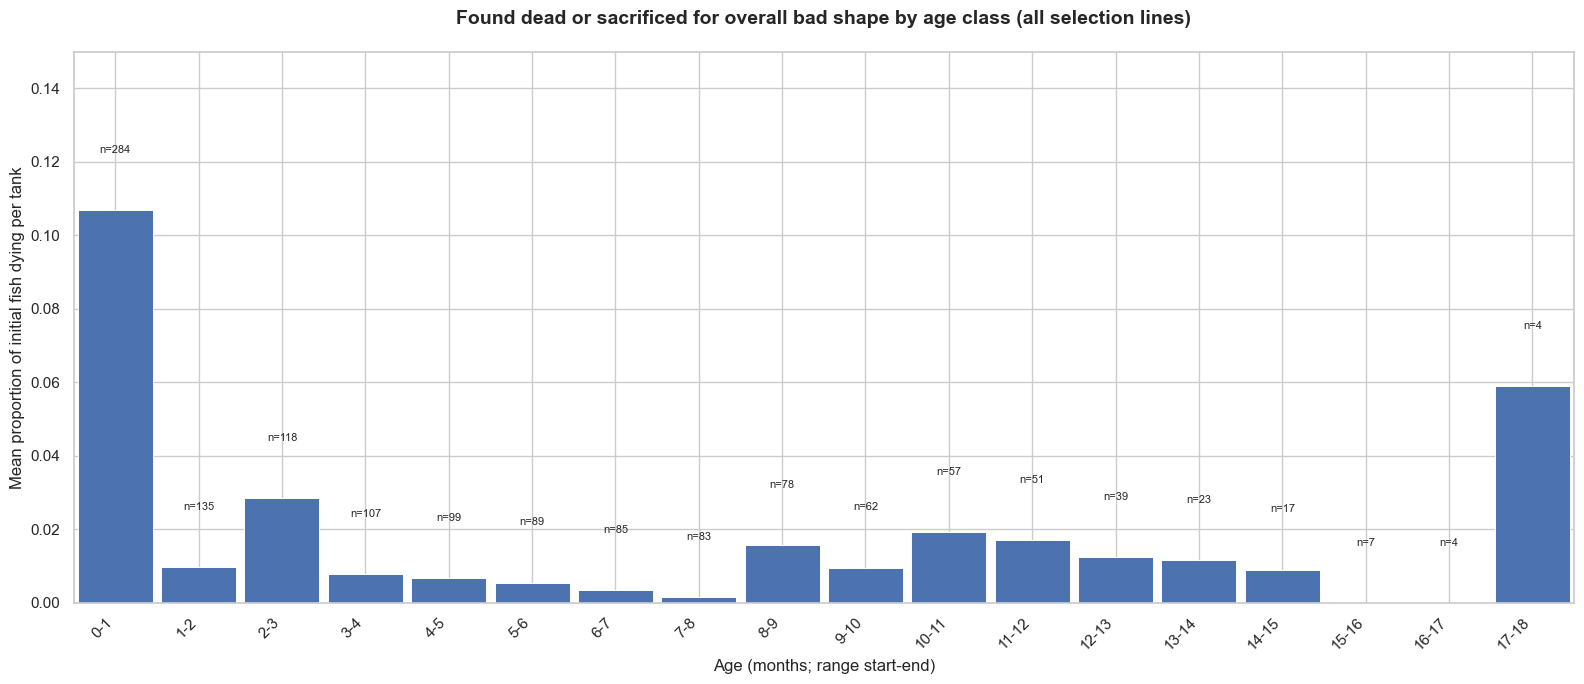

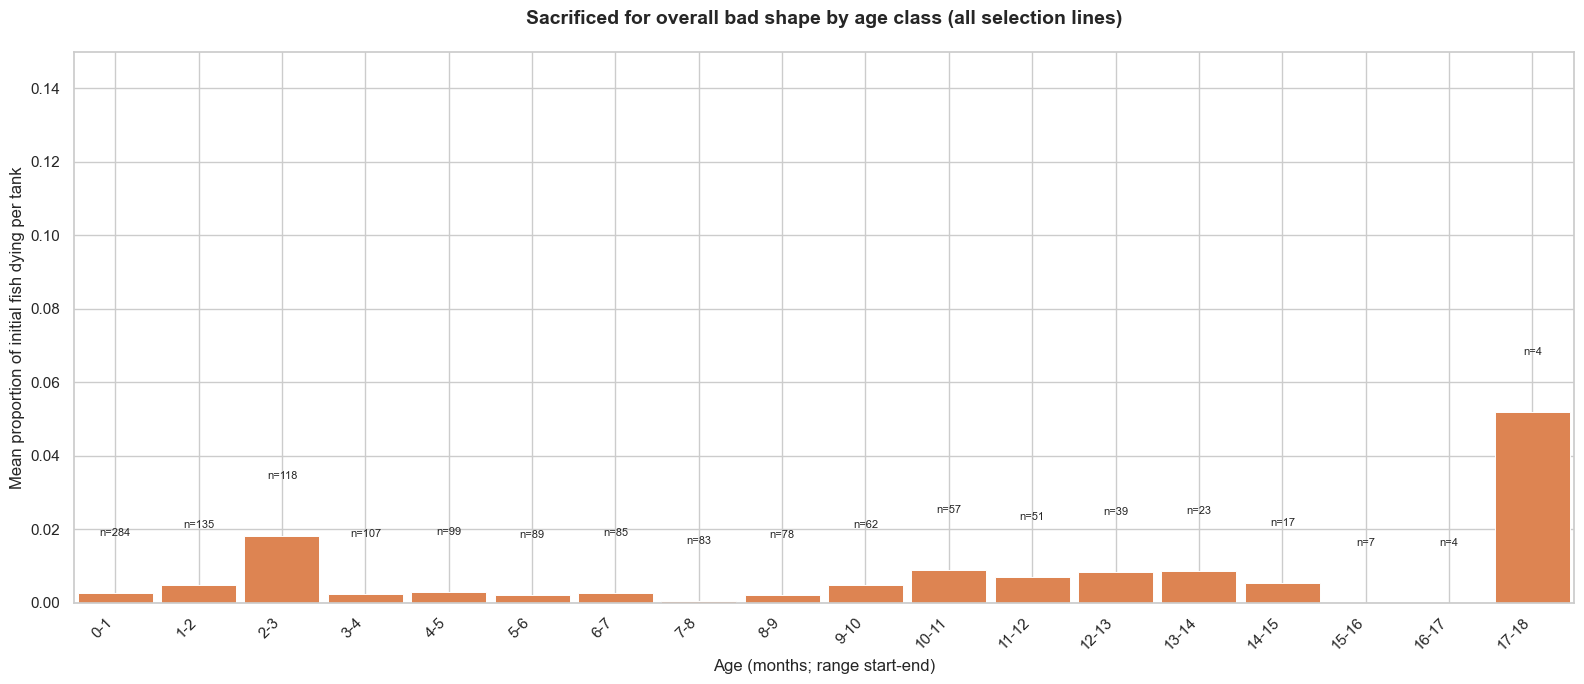

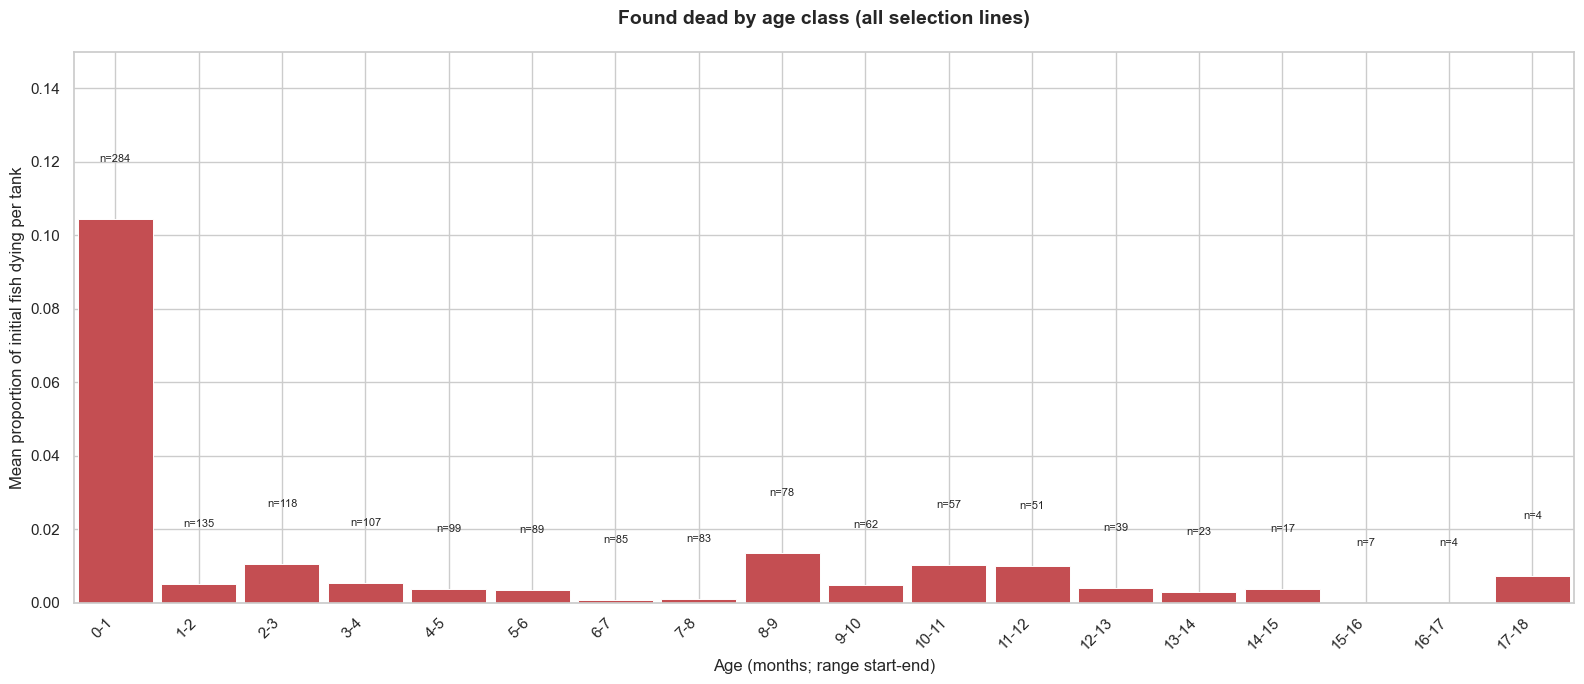

In [47]:
mortality_proportion_plots = [
    ("All qualifying mortality", "Found dead or sacrificed for overall bad shape", "#4C72B0"),
    ("Overall bad shape", "Sacrificed for overall bad shape", "#DD8452"),
    ("Found dead", "Found dead", "#C44E52"),
]
for mortality_category, title, color in mortality_proportion_plots:
    plot_summary = mortality_proportion_summary.loc[
        mortality_proportion_summary["mortality_category"].eq(mortality_category)
    ].copy()
    group_summary = mortality_group_proportion_summary.loc[
        mortality_group_proportion_summary["mortality_category"].eq(
            mortality_category
        )
    ].copy()
    bar_midpoints = (
        plot_summary["age_start_months"] + plot_summary["age_end_months"]
    ) / 2
    fig, ax = plt.subplots(figsize=(16, 7))
    if mortality_color_by == "none":
        ax.bar(
            bar_midpoints,
            plot_summary["mean_proportion_dying"],
            width=0.9 * mortality_proportion_bin_months,
            color=color,
            edgecolor="white",
            linewidth=0.7,
        )
    else:
        contribution_totals = group_summary.groupby(
            "mortality_group", observed=True
        )["mean_proportion_contribution"].sum()
        represented_groups = set(
            contribution_totals.loc[contribution_totals.gt(0)].index
        )
        stack_group_order = [
            group_name
            for group_name in mortality_group_order
            if group_name in represented_groups
        ]
        stack_values = (
            group_summary.pivot(
                index="age_class_months",
                columns="mortality_group",
                values="mean_proportion_contribution",
            )
            .reindex(
                index=plot_summary["age_class_months"],
                columns=stack_group_order,
                fill_value=0,
            )
            .fillna(0)
        )
        bar_bottoms = np.zeros(len(plot_summary), dtype=float)
        for group_name in stack_group_order:
            group_contributions = stack_values[group_name].to_numpy(dtype=float)
            ax.bar(
                bar_midpoints,
                group_contributions,
                width=0.9 * mortality_proportion_bin_months,
                bottom=bar_bottoms,
                color=mortality_group_palette[group_name],
                edgecolor="white",
                linewidth=0.7,
                label=group_name,
            )
            bar_bottoms += group_contributions
        if stack_group_order:
            ax.legend(
                bbox_to_anchor=(1.02, 1),
                loc="upper left",
                borderaxespad=0,
                ncols=2,
                fontsize=8,
                title=mortality_legend_title,
            )
    for midpoint, proportion, tank_count in zip(
        bar_midpoints,
        plot_summary["mean_proportion_dying"],
        plot_summary["tank_count"],
    ):
        label_y = proportion + 0.015 if proportion <= 0.95 else proportion - 0.03
        ax.text(
            midpoint,
            label_y,
            f"n={int(tank_count)}",
            ha="center",
            va="bottom" if proportion <= 0.95 else "top",
            fontsize=8,
        )
    ax.set_xticks(bar_midpoints)
    ax.set_xticklabels(plot_summary["age_class_months"], rotation=45, ha="right")
    ax.set(
        xlabel="Age (months; range start-end)",
        ylabel="Mean proportion of initial fish dying per tank",
        xlim=(mortality_proportion_bin_edges[0], mortality_proportion_bin_edges[-1]),
        ylim=(0, 0.15),
    )
    ax.set_title(
        f"{title} by age class ({mortality_line_label})",
        pad=20,
        fontsize=14,
        fontweight="bold",
    )
    fig.tight_layout()
    plt.show()